# Notebook 21 — Stronger SEI Diagnostic Branch Audit

## Goal

This notebook audits whether the stronger SEI-only aging checkpoints established in Notebook 20 produce clearer downstream diagnostic signals.

Notebook 20 confirmed that 0/20/50/100-cycle SEI-only aging checkpoints provide monotonic and amplified degradation-state variables. Notebook 21 now tests whether these stronger aging states become visible in diagnostic branches.

## Scientific context

Previous notebooks established the diagnostic toolchain:

- Notebook 15: Metric Registry v0.1
- Notebook 16: fixed-endpoint pseudo-OCV feasibility
- Notebook 17: C/25 OCV-like / ICA / DVA feasibility
- Notebook 18: C/25 vs C/50 slow-rate validation
- Notebook 19: GITT-like finite-rest OCV reconstruction
- Notebook 20: stronger SEI-only aging checkpoints at 0/20/50/100 cycles

Notebook 20 showed that the degradation-state signal at 100 cycles is approximately 3.06× stronger than at 20 cycles, but absolute degradation remains moderate.

Notebook 21 therefore asks:

> Do stronger SEI-only aging checkpoints produce clearer diagnostic observables?

## Study design

Aging branch:

- Parameter set: OKane2022
- Aging mechanism: solvent-diffusion-limited SEI only
- Plating: disabled
- LAM: disabled
- particle mechanics: disabled
- SEI porosity change: disabled
- thermal model: isothermal

Checkpoints:

- 0 cycles
- 20 cycles
- 50 cycles
- 100 cycles

Phase A diagnostic branch:

- capacity RPT / external capacity check
- start from pre-diagnostic full-charge-rest aging checkpoint
- for 0-cycle reference, use `initial_soc = 1.0`
- discharge at C/3 to 2.5 V
- rest for 60 min

## Workflow

1. Rebuild 0/20/50/100-cycle SEI-only aging checkpoints.
2. Extract degradation-state variables.
3. Run capacity RPT branches from each checkpoint.
4. Select the final diagnostic C/3 discharge segment.
5. Extract discharge capacity and endpoint descriptors.
6. Compare capacity fade with SEI thickness, LLI, lithium loss, and SEI capacity loss.
7. Classify whether capacity RPT becomes a stronger downstream observable.

## Expected outputs

Data files:

- `data/stronger_sei_diag_aging_state_table.csv`
- `data/stronger_sei_diag_capacity_segment_audit.csv`
- `data/stronger_sei_diag_capacity_selected_segment_audit.csv`
- `data/stronger_sei_diag_capacity_rpt_table.csv`
- `data/stronger_sei_diag_capacity_linkage_audit.csv`
- `data/stronger_sei_diag_capacity_classification_table.csv`

Figures:

- `figures/stronger_sei_diag_capacity_retention.png`
- `figures/stronger_sei_diag_capacity_vs_degradation.png`

## Interpretation boundary

This phase audits capacity-level diagnostic observability only.

A monotonic capacity fade trend supports capacity RPT as a degradation-sensitive observable for the stronger SEI-only branch, but it does not establish mechanism uniqueness. Mechanism uniqueness requires comparison against other degradation modes such as plating or LAM.

C/25 OCV-like V(Q), GITT-like finite-rest OCV reconstruction, ICA, and DVA are deferred until Phase A confirms the stronger-checkpoint capacity signal.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


## Methodological boundary before code execution

Notebook 21 starts with capacity RPT only.

This notebook must not yet overinterpret voltage-curve, ICA, DVA, or GITT-like features. Those branches are deferred until capacity-level diagnostic observability is confirmed.

The diagnostic branch must not be used to continue aging.

In [2]:
# Cell 2 — SEI-only OKane2022 model builder（SEI-only OKane2022 模型构建函数）

def build_sei_only_model():
    """
    Build DFN model with solvent-diffusion-limited SEI only.
    Other degradation mechanisms are disabled to keep the fingerprint source isolated.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }
    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")
    return model, parameter_values


def make_solver():
    """Create a conservative CasADi solver for degradation-enabled DFN runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


model_smoke, pv_smoke = build_sei_only_model()

print("[OK] SEI-only OKane2022 DFN model instantiated.")
print("[MODEL]", model_smoke.name)

[OK] SEI-only OKane2022 DFN model instantiated.
[MODEL] Doyle-Fuller-Newman model


In [3]:
# Cell 3 — Stronger-checkpoint capacity RPT protocol constants（增强检查点容量 RPT 协议常数）

CHECKPOINT_CYCLES = [0, 20, 50, 100]

AGING_PERIOD = "120 seconds"

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

REFERENCE_REST_STEP = ["Rest for 10 minutes"]

CAPACITY_RPT_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 60 minutes",
]

CAPACITY_RPT_PERIOD = "60 seconds"

# OKane2022 nominal capacity is about 5 Ah, so C/3 ≈ 1.67 A.
CAPACITY_RPT_CURRENT_LO_A = 1.40
CAPACITY_RPT_CURRENT_HI_A = 1.90
CAPACITY_RPT_DURATION_LO_MIN = 150
CAPACITY_RPT_DURATION_HI_MIN = 230

print("[CONFIG] checkpoints:", CHECKPOINT_CYCLES)
print("[CONFIG] aging period:", AGING_PERIOD)
print("[CONFIG] capacity RPT steps:")
for step in CAPACITY_RPT_STEPS:
    print("  -", step)

print("[OK] Protocol constants defined.")

[CONFIG] checkpoints: [0, 20, 50, 100]
[CONFIG] aging period: 120 seconds
[CONFIG] capacity RPT steps:
  - Discharge at C/3 until 2.5 V
  - Rest for 60 minutes
[OK] Protocol constants defined.


In [4]:
# Cell 4 — Stronger SEI aging checkpoints and degradation-state extraction（增强 SEI 老化检查点与状态变量提取）

VARIABLE_CANDIDATES = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative electrode SEI thickness [m]",
    ],
    "lli_percent": [
        "Loss of lithium inventory [%]",
        "Loss of lithium inventory, LLI [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Loss of lithium to SEI [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "sei_capacity_loss_Ah": [
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
        "Loss of capacity to SEI on negative electrode [A.h]",
        "Loss of capacity to side reactions [A.h]",
        "Total capacity lost to side reactions [A.h]",
    ],
}


def run_initial_reference_state(initial_soc=1.0):
    """
    Generate a 0-cycle reference solution for extracting initial degradation variables.
    This reference is not used to continue aging.
    """
    model, pv = build_sei_only_model()
    experiment = pybamm.Experiment(REFERENCE_REST_STEP, period=AGING_PERIOD)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    sol = sim.solve(initial_soc=initial_soc)
    return sol


def make_aging_experiment(n_cycles, period=AGING_PERIOD):
    """Build repeated SEI-only aging experiment."""
    if n_cycles == 0:
        return None
    return pybamm.Experiment([tuple(AGING_CYCLE_STEPS)] * n_cycles, period=period)


def run_aging_segment(n_cycles, starting_solution=None, initial_soc=None):
    """
    Run n_cycles of SEI-only aging.
    Returned solution is a pre-diagnostic aging state.
    """
    if n_cycles == 0:
        return starting_solution

    model, pv = build_sei_only_model()
    experiment = make_aging_experiment(n_cycles)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    if initial_soc is not None:
        kwargs["initial_soc"] = initial_soc

    sol = sim.solve(**kwargs)
    return sol


def get_last_scalar(sol, candidates):
    """
    Return last scalar value from the first available PyBaMM variable candidate.
    If the variable is spatially resolved, use the last-time mean as fallback.
    """
    for name in candidates:
        try:
            entries = np.asarray(sol[name].entries, dtype=float)

            if entries.ndim == 0:
                value = float(entries)
            elif entries.ndim == 1:
                value = float(entries[-1])
            else:
                value = float(np.nanmean(entries[..., -1]))

            return value, name
        except Exception:
            continue

    return np.nan, None


checkpoint_solutions = {}

print("[RUN] Generating 0-cycle reference state")
checkpoint_solutions[0] = run_initial_reference_state(initial_soc=1.0)
print("[OK] checkpoint stored: 0 cycles")

current_solution = None
current_cycle = 0

t_start_all = time.perf_counter()

for target_cycle in CHECKPOINT_CYCLES[1:]:
    n_more = target_cycle - current_cycle
    print("")
    print(f"[RUN] Aging from cycle {current_cycle} to {target_cycle} ({n_more} cycles)")
    t_start = time.perf_counter()

    current_solution = run_aging_segment(
        n_cycles=n_more,
        starting_solution=current_solution,
        initial_soc=1.0 if current_cycle == 0 else None,
    )

    checkpoint_solutions[target_cycle] = current_solution
    current_cycle = target_cycle

    elapsed_min = (time.perf_counter() - t_start) / 60
    print(f"[OK] checkpoint stored: {target_cycle} cycles | elapsed = {elapsed_min:.2f} min")

elapsed_all_min = (time.perf_counter() - t_start_all) / 60

print("")
print("[OK] Stronger aging checkpoint generation complete.")
print("[CHECKPOINTS]", sorted(checkpoint_solutions.keys()))
print(f"[RUNTIME] total aging runtime = {elapsed_all_min:.2f} min")

state_rows = []

for cycle in CHECKPOINT_CYCLES:
    sol = checkpoint_solutions[cycle]
    row = {"cycle": cycle}

    for metric, candidates in VARIABLE_CANDIDATES.items():
        value, used_name = get_last_scalar(sol, candidates)
        row[metric] = value
        row[f"{metric}_source"] = used_name

    state_rows.append(row)

aging_state_table = pd.DataFrame(state_rows)

state_path = DATA / "stronger_sei_diag_aging_state_table.csv"
aging_state_table.to_csv(state_path, index=False)

print(f"[OK] saved: {state_path}")
display(aging_state_table)

[RUN] Generating 0-cycle reference state
[OK] checkpoint stored: 0 cycles

[RUN] Aging from cycle 0 to 20 (20 cycles)
[OK] checkpoint stored: 20 cycles | elapsed = 0.31 min

[RUN] Aging from cycle 20 to 50 (30 cycles)
[OK] checkpoint stored: 50 cycles | elapsed = 0.46 min

[RUN] Aging from cycle 50 to 100 (50 cycles)
[OK] checkpoint stored: 100 cycles | elapsed = 0.78 min

[OK] Stronger aging checkpoint generation complete.
[CHECKPOINTS] [0, 20, 50, 100]
[RUNTIME] total aging runtime = 1.54 min
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_aging_state_table.csv


,cycle,sei_thickness_m,sei_thickness_m_source,lli_percent,lli_percent_source,total_lithium_lost_mol,total_lithium_lost_mol_source,sei_capacity_loss_Ah,sei_capacity_loss_Ah_source
0,0,5.007573e-09,X-averaged negative SEI thickness [m],0.000093,Loss of lithium inventory [%],2.654362e-07,Total lithium lost [mol],0.000007,Loss of capacity to negative SEI [A.h]
1,20,9.471876e-09,X-averaged negative SEI thickness [m],0.055198,Loss of lithium inventory [%],1.567446e-04,Total lithium lost [mol],0.004201,Loss of capacity to negative SEI [A.h]
2,50,1.366499e-08,X-averaged negative SEI thickness [m],0.106956,Loss of lithium inventory [%],3.037184e-04,Total lithium lost [mol],0.008140,Loss of capacity to negative SEI [A.h]
3,100,1.866443e-08,X-averaged negative SEI thickness [m],0.168666,Loss of lithium inventory [%],4.789546e-04,Total lithium lost [mol],0.012837,Loss of capacity to negative SEI [A.h]


In [5]:
# Cell 5 — Capacity RPT diagnostic branch runner（容量 RPT 诊断分支运行）

def make_capacity_rpt_experiment():
    """Build diagnostic-only capacity RPT branch."""
    return pybamm.Experiment(CAPACITY_RPT_STEPS, period=CAPACITY_RPT_PERIOD)


def run_capacity_rpt_diagnostic(cycle, starting_solution=None):
    """
    Run C/3 discharge capacity RPT from a pre-diagnostic aging checkpoint.

    No repeated full-charge preconditioning is applied because the aging checkpoint
    already ends after charge-to-4.2V, CV hold, and 10 min rest.
    """
    model, pv = build_sei_only_model()
    experiment = make_capacity_rpt_experiment()

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] Capacity RPT diagnostic branch: cycle={cycle}")
    sol = sim.solve(**kwargs)
    print(f"[OK] solved: cycle={cycle}")
    return sol


capacity_rpt_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    capacity_rpt_solutions[cycle] = run_capacity_rpt_diagnostic(
        cycle=cycle,
        starting_solution=checkpoint_solutions[cycle],
    )

print("[OK] All capacity RPT diagnostic branches solved.")
print("[N solutions]", len(capacity_rpt_solutions))

[RUN] Capacity RPT diagnostic branch: cycle=0
[OK] solved: cycle=0
[RUN] Capacity RPT diagnostic branch: cycle=20


At t = 454.577, , mxstep steps taken before reaching tout.


[OK] solved: cycle=20
[RUN] Capacity RPT diagnostic branch: cycle=50


At t = 446.584, , mxstep steps taken before reaching tout.


[OK] solved: cycle=50
[RUN] Capacity RPT diagnostic branch: cycle=100
[OK] solved: cycle=100
[OK] All capacity RPT diagnostic branches solved.
[N solutions] 4


In [6]:
# Cell 6 — Capacity RPT segment audit（容量 RPT 分段审计）

def summarize_current_segments(sol, cycle, eps=1e-4):
    """
    Summarize sign-based current segments.

    PyBaMM sign convention:
    +I = discharge
    -I = charge
    near-zero = rest / cutoff
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "cycle": cycle,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


all_segments = []
selected_segments = []

for cycle, sol in capacity_rpt_solutions.items():
    seg = summarize_current_segments(sol, cycle)
    all_segments.append(seg)

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(CAPACITY_RPT_CURRENT_LO_A, CAPACITY_RPT_CURRENT_HI_A))
        & (seg["duration_min"].between(CAPACITY_RPT_DURATION_LO_MIN, CAPACITY_RPT_DURATION_HI_MIN))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid C/3 capacity RPT discharge segment found for cycle={cycle}")

    # Use the last matching segment because starting_solution carries aging history.
    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    selected["selection_rule"] = (
        f"last discharge segment with "
        f"{CAPACITY_RPT_CURRENT_LO_A} <= I_mean <= {CAPACITY_RPT_CURRENT_HI_A} A "
        f"and {CAPACITY_RPT_DURATION_LO_MIN} <= duration <= {CAPACITY_RPT_DURATION_HI_MIN} min"
    )
    selected_segments.append(selected)

capacity_segment_audit = pd.concat(all_segments, ignore_index=True)
capacity_selected_segment_audit = pd.DataFrame(selected_segments)

segment_path = DATA / "stronger_sei_diag_capacity_segment_audit.csv"
selected_path = DATA / "stronger_sei_diag_capacity_selected_segment_audit.csv"

capacity_segment_audit.to_csv(segment_path, index=False)
capacity_selected_segment_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(capacity_selected_segment_audit[[
    "cycle", "segment_id", "duration_min", "U_start_V", "U_end_V",
    "I_mean_A", "n_points", "selection_rule"
]])

print("[OK] Capacity RPT selected discharge segments passed audit.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_capacity_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_capacity_selected_segment_audit.csv


,cycle,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points,selection_rule
0,0,1,181.782633,4.130154,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
1,20,80,181.219609,4.124349,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
2,50,200,181.086009,4.124077,2.50001,1.666667,183,last discharge segment with 1.4 <= I_mean <= 1...
3,100,400,180.928896,4.123773,2.50001,1.666667,182,last discharge segment with 1.4 <= I_mean <= 1...


[OK] Capacity RPT selected discharge segments passed audit.


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_capacity_rpt_table.csv


,Q_dis_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points,cycle,selected_segment_id,capacity_retention_pct,capacity_fade_pct,capacity_loss_Ah_vs_0
0,5.049518,4.130154,2.50001,1.666667,181.782633,183,0,1,100.000000,0.000000,0.000000
1,5.033878,4.124349,2.50001,1.666667,181.219609,183,20,80,99.690276,0.309724,0.015640
2,5.030167,4.124077,2.50001,1.666667,181.086009,183,50,200,99.616782,0.383218,0.019351
3,5.025803,4.123773,2.50001,1.666667,180.928896,182,100,400,99.530353,0.469647,0.023715


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_capacity_linkage_audit.csv


,degradation_metric,capacity_loss_corr,metric_0,metric_100,capacity_loss_100_Ah
0,sei_thickness_m,0.930701,5.007573e-09,1.866443e-08,0.023715
1,lli_percent,0.930701,9.347460e-05,1.686661e-01,0.023715
2,total_lithium_lost_mol,0.930701,2.654362e-07,4.789546e-04,0.023715
3,sei_capacity_loss_Ah,0.930701,7.114083e-06,1.283669e-02,0.023715


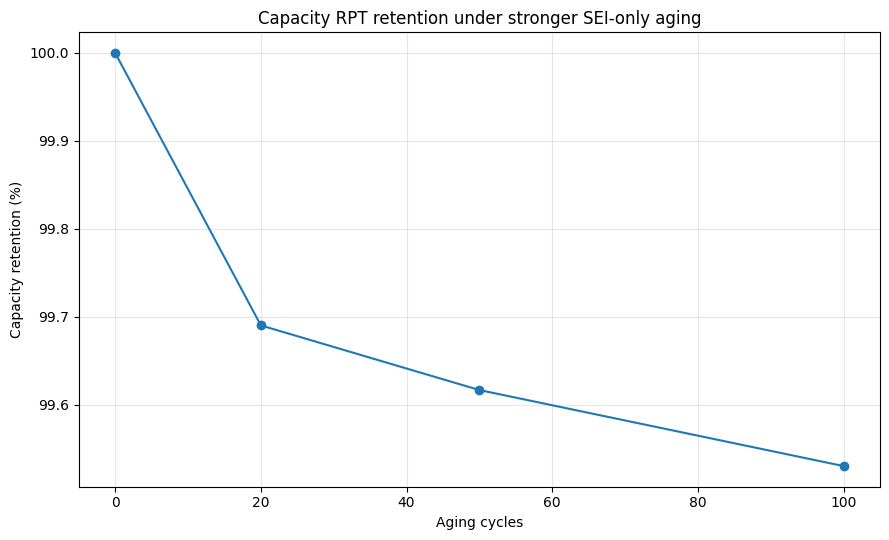

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_capacity_retention.png


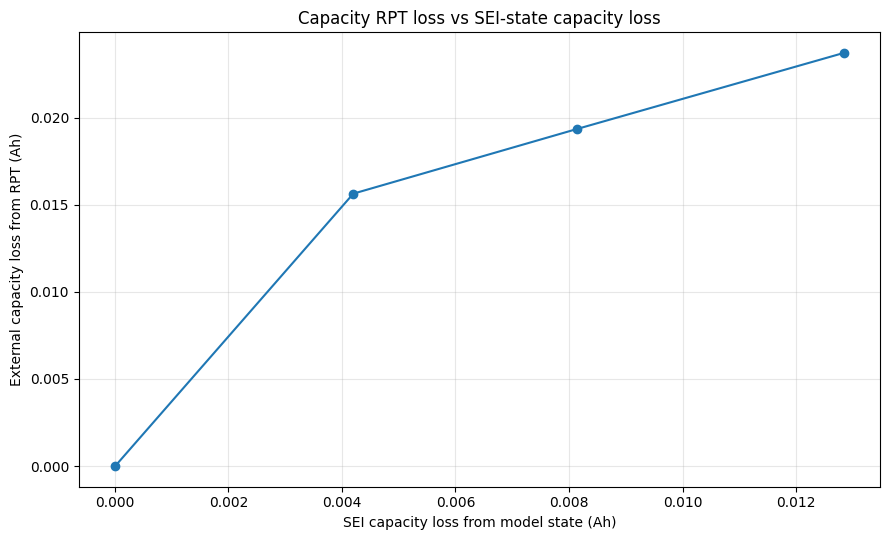

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_capacity_vs_degradation.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_capacity_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,All selected C/3 capacity RPT discharge segmen...,strong,capacity RPT diagnostic segments are valid
1,capacity_fade,"100-cycle capacity fade = 0.4696 %, capacity l...",data-backed,external capacity fade is quantifiable
2,monotonicity,Q_dis decreases monotonically with aging = True.,strong,capacity RPT follows aging severity
3,linkage,Capacity loss was compared against SEI thickne...,audit-level,capacity RPT can be linked to degradation-stat...
4,overall,Capacity RPT was run at 0/20/50/100-cycle SEI-...,supported,capacity RPT detects stronger SEI-only aging


In [7]:
# Cell 7 — Capacity RPT extraction and degradation linkage audit（容量 RPT 提取与老化状态关联审计）

def integrate_selected_capacity_Ah(sol, idx_start, idx_stop):
    """Integrate selected positive discharge current segment."""
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    t_rel_s = t - t[0]
    q_Ah = np.zeros_like(t_rel_s)

    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    return {
        "Q_dis_Ah": float(q_Ah[-1]),
        "U_start_V": float(v[0]),
        "U_end_V": float(v[-1]),
        "I_mean_A": float(np.mean(i)),
        "duration_min": float(t_rel_s[-1] / 60),
        "n_points": int(len(t_rel_s)),
    }


capacity_rows = []

for cycle, sol in capacity_rpt_solutions.items():
    selected = capacity_selected_segment_audit[capacity_selected_segment_audit["cycle"] == cycle].iloc[0]

    cap = integrate_selected_capacity_Ah(
        sol=sol,
        idx_start=int(selected["idx_start"]),
        idx_stop=int(selected["idx_stop"]),
    )

    cap["cycle"] = cycle
    cap["selected_segment_id"] = int(selected["segment_id"])
    capacity_rows.append(cap)

capacity_rpt_table = pd.DataFrame(capacity_rows).sort_values("cycle").reset_index(drop=True)

q0 = float(capacity_rpt_table.loc[capacity_rpt_table["cycle"] == 0, "Q_dis_Ah"].iloc[0])
capacity_rpt_table["capacity_retention_pct"] = capacity_rpt_table["Q_dis_Ah"] / q0 * 100
capacity_rpt_table["capacity_fade_pct"] = 100 - capacity_rpt_table["capacity_retention_pct"]
capacity_rpt_table["capacity_loss_Ah_vs_0"] = q0 - capacity_rpt_table["Q_dis_Ah"]

capacity_path = DATA / "stronger_sei_diag_capacity_rpt_table.csv"
capacity_rpt_table.to_csv(capacity_path, index=False)

print(f"[OK] saved: {capacity_path}")
display(capacity_rpt_table)

# Link capacity fade to degradation-state variables
linkage = capacity_rpt_table.merge(aging_state_table, on="cycle", how="left")

linkage_rows = []

for metric in ["sei_thickness_m", "lli_percent", "total_lithium_lost_mol", "sei_capacity_loss_Ah"]:
    x = linkage[metric].to_numpy(dtype=float)
    y = linkage["capacity_loss_Ah_vs_0"].to_numpy(dtype=float)

    if np.isfinite(x).all() and np.isfinite(y).all() and len(x) >= 3:
        corr = float(np.corrcoef(x, y)[0, 1])
    else:
        corr = np.nan

    linkage_rows.append({
        "degradation_metric": metric,
        "capacity_loss_corr": corr,
        "metric_0": float(linkage.loc[linkage["cycle"] == 0, metric].iloc[0]),
        "metric_100": float(linkage.loc[linkage["cycle"] == 100, metric].iloc[0]),
        "capacity_loss_100_Ah": float(linkage.loc[linkage["cycle"] == 100, "capacity_loss_Ah_vs_0"].iloc[0]),
    })

capacity_linkage_audit = pd.DataFrame(linkage_rows)

linkage_path = DATA / "stronger_sei_diag_capacity_linkage_audit.csv"
capacity_linkage_audit.to_csv(linkage_path, index=False)

print(f"[OK] saved: {linkage_path}")
display(capacity_linkage_audit)

# Figures
plt.figure(figsize=(9, 5.5))
plt.plot(
    capacity_rpt_table["cycle"],
    capacity_rpt_table["capacity_retention_pct"],
    marker="o",
)
plt.xlabel("Aging cycles")
plt.ylabel("Capacity retention (%)")
plt.title("Capacity RPT retention under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_capacity_retention.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

plt.figure(figsize=(9, 5.5))
plt.plot(
    linkage["sei_capacity_loss_Ah"],
    linkage["capacity_loss_Ah_vs_0"],
    marker="o",
)
plt.xlabel("SEI capacity loss from model state (Ah)")
plt.ylabel("External capacity loss from RPT (Ah)")
plt.title("Capacity RPT loss vs SEI-state capacity loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_capacity_vs_degradation.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Classification table
capacity_loss_100 = float(capacity_rpt_table.loc[capacity_rpt_table["cycle"] == 100, "capacity_loss_Ah_vs_0"].iloc[0])
capacity_fade_100 = float(capacity_rpt_table.loc[capacity_rpt_table["cycle"] == 100, "capacity_fade_pct"].iloc[0])
is_capacity_monotonic = bool(np.all(np.diff(capacity_rpt_table["Q_dis_Ah"].to_numpy()) <= 1e-8))

if is_capacity_monotonic and capacity_fade_100 > 0.1:
    strength = "supported"
    verdict = "capacity RPT detects stronger SEI-only aging"
elif is_capacity_monotonic:
    strength = "partially supported"
    verdict = "capacity RPT detects monotonic but weak SEI-only aging"
else:
    strength = "deferred"
    verdict = "capacity RPT trend is not monotonic; diagnostic branch requires audit"

classification_table = pd.DataFrame([
    {
        "metric_layer": "segment_quality",
        "evidence": "All selected C/3 capacity RPT discharge segments passed current and duration audit.",
        "strength": "strong",
        "classification": "capacity RPT diagnostic segments are valid",
    },
    {
        "metric_layer": "capacity_fade",
        "evidence": f"100-cycle capacity fade = {capacity_fade_100:.4f} %, capacity loss = {capacity_loss_100:.6f} Ah.",
        "strength": "data-backed",
        "classification": "external capacity fade is quantifiable",
    },
    {
        "metric_layer": "monotonicity",
        "evidence": f"Q_dis decreases monotonically with aging = {is_capacity_monotonic}.",
        "strength": "strong" if is_capacity_monotonic else "insufficient",
        "classification": "capacity RPT follows aging severity" if is_capacity_monotonic else "capacity RPT does not follow aging severity",
    },
    {
        "metric_layer": "linkage",
        "evidence": "Capacity loss was compared against SEI thickness, LLI, lithium loss, and SEI capacity loss.",
        "strength": "audit-level",
        "classification": "capacity RPT can be linked to degradation-state metrics, but mechanism uniqueness is not yet proven",
    },
    {
        "metric_layer": "overall",
        "evidence": "Capacity RPT was run at 0/20/50/100-cycle SEI-only checkpoints.",
        "strength": strength,
        "classification": verdict,
    },
])

classification_path = DATA / "stronger_sei_diag_capacity_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

In [8]:
# Cell 8 — Stronger-checkpoint C/25 OCV-like diagnostic branch runner（增强检查点 C/25 OCV-like 诊断分支运行）

C25_OCV_STEPS = [
    "Discharge at C/25 until 2.5 V",
    "Rest for 60 minutes",
]

C25_OCV_PERIOD = "60 seconds"

# OKane2022 nominal capacity ≈ 5 Ah, so C/25 ≈ 0.2 A
C25_CURRENT_LO_A = 0.15
C25_CURRENT_HI_A = 0.25
C25_DURATION_LO_MIN = 1400
C25_DURATION_HI_MIN = 1650


def make_c25_ocv_experiment():
    """Build diagnostic-only C/25 OCV-like discharge branch."""
    return pybamm.Experiment(C25_OCV_STEPS, period=C25_OCV_PERIOD)


def run_c25_ocv_diagnostic(cycle, starting_solution=None):
    """
    Run C/25 OCV-like diagnostic branch from a pre-diagnostic aging checkpoint.

    No repeated full-charge preconditioning is applied because the aging checkpoint
    already ends after charge-to-4.2V, CV hold, and 10 min rest.
    """
    model, pv = build_sei_only_model()
    experiment = make_c25_ocv_experiment()

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] C/25 OCV-like diagnostic branch: cycle={cycle}")
    sol = sim.solve(**kwargs)
    print(f"[OK] solved: cycle={cycle}")
    return sol


c25_ocv_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    c25_ocv_solutions[cycle] = run_c25_ocv_diagnostic(
        cycle=cycle,
        starting_solution=checkpoint_solutions[cycle],
    )

print("[OK] All C/25 OCV-like diagnostic branches solved.")
print("[N solutions]", len(c25_ocv_solutions))

[RUN] C/25 OCV-like diagnostic branch: cycle=0
[OK] solved: cycle=0
[RUN] C/25 OCV-like diagnostic branch: cycle=20
[OK] solved: cycle=20
[RUN] C/25 OCV-like diagnostic branch: cycle=50
[OK] solved: cycle=50
[RUN] C/25 OCV-like diagnostic branch: cycle=100
[OK] solved: cycle=100
[OK] All C/25 OCV-like diagnostic branches solved.
[N solutions] 4


In [9]:
# Cell 9 — C/25 selected segment audit and V(Q) extraction（C/25 选段审计与 V(Q) 提取）

c25_all_segments = []
c25_selected_segments = []

for cycle, sol in c25_ocv_solutions.items():
    seg = summarize_current_segments(sol, cycle)
    c25_all_segments.append(seg)

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(C25_CURRENT_LO_A, C25_CURRENT_HI_A))
        & (seg["duration_min"].between(C25_DURATION_LO_MIN, C25_DURATION_HI_MIN))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid C/25 diagnostic discharge segment found for cycle={cycle}")

    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    selected["selection_rule"] = (
        f"last discharge segment with "
        f"{C25_CURRENT_LO_A} <= I_mean <= {C25_CURRENT_HI_A} A "
        f"and {C25_DURATION_LO_MIN} <= duration <= {C25_DURATION_HI_MIN} min"
    )
    c25_selected_segments.append(selected)

c25_segment_audit = pd.concat(c25_all_segments, ignore_index=True)
c25_selected_segment_audit = pd.DataFrame(c25_selected_segments)

segment_path = DATA / "stronger_sei_diag_c25_segment_audit.csv"
selected_path = DATA / "stronger_sei_diag_c25_selected_segment_audit.csv"

c25_segment_audit.to_csv(segment_path, index=False)
c25_selected_segment_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(c25_selected_segment_audit[[
    "cycle", "segment_id", "duration_min", "U_start_V", "U_end_V",
    "I_mean_A", "n_points", "selection_rule"
]])


def extract_selected_c25_curve(sol, cycle, selected_segment_table):
    """Extract selected C/25 diagnostic discharge curve."""
    selected = selected_segment_table[selected_segment_table["cycle"] == cycle]
    if selected.empty:
        raise RuntimeError(f"No selected C/25 segment for cycle={cycle}")

    row = selected.iloc[0]
    a = int(row["idx_start"])
    b = int(row["idx_stop"])

    t = np.asarray(sol["Time [s]"].entries, dtype=float)[a:b]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[a:b]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[a:b]

    t_rel_s = t - t[0]

    q_Ah = np.zeros_like(t_rel_s)
    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    q_end_Ah = float(q_Ah[-1])
    nominal_soc = 1.0 - q_Ah / q_end_Ah if q_end_Ah > 0 else np.nan

    return pd.DataFrame({
        "cycle": cycle,
        "t_rel_s": t_rel_s,
        "t_rel_h": t_rel_s / 3600.0,
        "Q_dis_Ah": q_Ah,
        "nominal_SOC": nominal_soc,
        "U_V": v,
        "I_A_pybamm": i,
        "segment_id": int(row["segment_id"]),
    })


c25_curve_tables = []

for cycle, sol in c25_ocv_solutions.items():
    c25_curve_tables.append(
        extract_selected_c25_curve(
            sol=sol,
            cycle=cycle,
            selected_segment_table=c25_selected_segment_audit,
        )
    )

c25_curve_table = pd.concat(c25_curve_tables, ignore_index=True)

curve_path = DATA / "stronger_sei_diag_c25_curve_table.csv"
c25_curve_table.to_csv(curve_path, index=False)

c25_curve_summary = (
    c25_curve_table
    .groupby("cycle", as_index=False)
    .agg(
        n_points=("Q_dis_Ah", "size"),
        Q_end_Ah=("Q_dis_Ah", "max"),
        U_start_V=("U_V", "first"),
        U_end_V=("U_V", "last"),
        I_mean_A=("I_A_pybamm", "mean"),
        t_end_h=("t_rel_h", "max"),
        selected_segment_id=("segment_id", "first"),
    )
)

summary_path = DATA / "stronger_sei_diag_c25_curve_summary.csv"
c25_curve_summary.to_csv(summary_path, index=False)

print(f"[OK] saved: {curve_path}")
print(f"[OK] saved: {summary_path}")
display(c25_curve_summary)

print("[OK] C/25 selected segment audit and V(Q) extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_selected_segment_audit.csv


,cycle,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points,selection_rule
0,0,1,1530.185453,4.190343,2.50001,0.2,1532,last discharge segment with 0.15 <= I_mean <= ...
1,20,80,1525.629718,4.184936,2.50001,0.2,1527,last discharge segment with 0.15 <= I_mean <= ...
2,50,200,1524.584855,4.184932,2.50001,0.2,1526,last discharge segment with 0.15 <= I_mean <= ...
3,100,400,1523.333350,4.184949,2.50001,0.2,1525,last discharge segment with 0.15 <= I_mean <= ...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_curve_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_curve_summary.csv


,cycle,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A,t_end_h,selected_segment_id
0,0,1532,5.100618,4.190343,2.50001,0.2,25.503091,1
1,20,1527,5.085432,4.184936,2.50001,0.2,25.427162,80
2,50,1526,5.081950,4.184932,2.50001,0.2,25.409748,200
3,100,1525,5.077778,4.184949,2.50001,0.2,25.388889,400


[OK] C/25 selected segment audit and V(Q) extraction complete.


In [10]:
# Cell 10 — C/25 V(Q) quality and voltage-drift audit（C/25 V(Q) 质量与电压漂移审计）

quality_rows = []

for cycle, g in c25_curve_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    dQ = np.diff(g["Q_dis_Ah"].to_numpy())
    dV = np.diff(g["U_V"].to_numpy())

    n_points = len(g)
    q_end = float(g["Q_dis_Ah"].iloc[-1])
    v_start = float(g["U_V"].iloc[0])
    v_end = float(g["U_V"].iloc[-1])
    voltage_span = v_start - v_end

    q_nonmono = int(np.sum(dQ <= 0))
    v_increase_count = int(np.sum(dV > 1e-5))
    v_increase_fraction = v_increase_count / max(len(dV), 1)

    median_dQ_mAh = float(np.median(dQ) * 1000) if len(dQ) else np.nan
    median_abs_dV_mV = float(np.median(np.abs(dV)) * 1000) if len(dV) else np.nan

    pass_quality = (
        n_points >= 1000
        and q_end > 1.0
        and voltage_span > 1.0
        and q_nonmono == 0
        and v_increase_fraction < 0.01
    )

    quality_rows.append({
        "cycle": cycle,
        "n_points": n_points,
        "Q_end_Ah": q_end,
        "U_start_V": v_start,
        "U_end_V": v_end,
        "voltage_span_V": voltage_span,
        "Q_nonmonotonic_count": q_nonmono,
        "V_local_increase_count": v_increase_count,
        "V_local_increase_fraction": v_increase_fraction,
        "median_dQ_mAh": median_dQ_mAh,
        "median_abs_dV_mV": median_abs_dV_mV,
        "pass_curve_quality": pass_quality,
    })

c25_quality_audit = pd.DataFrame(quality_rows)

quality_path = DATA / "stronger_sei_diag_c25_quality_audit.csv"
c25_quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(c25_quality_audit)

assert c25_quality_audit["pass_curve_quality"].all(), "At least one C/25 V(Q) curve failed quality audit."

# Common-Q grid
q_common_max = float(c25_curve_summary["Q_end_Ah"].min())
q_grid = np.linspace(0.02, q_common_max - 0.02, 1200)

interp_rows = []

for cycle, g in c25_curve_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    q = g["Q_dis_Ah"].to_numpy()
    v = g["U_V"].to_numpy()

    v_interp = np.interp(q_grid, q, v)

    interp_rows.append(pd.DataFrame({
        "cycle": cycle,
        "Q_dis_Ah": q_grid,
        "U_interp_V": v_interp,
    }))

c25_interp_table = pd.concat(interp_rows, ignore_index=True)

base = (
    c25_interp_table[c25_interp_table["cycle"] == 0]
    .set_index("Q_dis_Ah")["U_interp_V"]
)

drift_rows = []
drift_curve_rows = []

for cycle in CHECKPOINT_CYCLES:
    g = (
        c25_interp_table[c25_interp_table["cycle"] == cycle]
        .set_index("Q_dis_Ah")["U_interp_V"]
    )

    delta_mV = (g - base) * 1000

    drift_rows.append({
        "cycle": cycle,
        "Q_common_max_Ah": q_common_max,
        "deltaU_mean_mV": float(delta_mV.mean()),
        "deltaU_median_mV": float(delta_mV.median()),
        "deltaU_min_mV": float(delta_mV.min()),
        "deltaU_max_mV": float(delta_mV.max()),
        "deltaU_max_abs_mV": float(np.max(np.abs(delta_mV))),
        "deltaU_p95_abs_mV": float(np.percentile(np.abs(delta_mV), 95)),
        "deltaU_start_mV": float(delta_mV.iloc[0]),
        "deltaU_end_mV": float(delta_mV.iloc[-1]),
    })

    drift_curve_rows.append(pd.DataFrame({
        "cycle": cycle,
        "Q_dis_Ah": q_grid,
        "deltaU_vs_0_mV": delta_mV.to_numpy(),
    }))

c25_voltage_drift_audit = pd.DataFrame(drift_rows)
c25_voltage_drift_curve = pd.concat(drift_curve_rows, ignore_index=True)

drift_path = DATA / "stronger_sei_diag_c25_voltage_drift_audit.csv"
drift_curve_path = DATA / "stronger_sei_diag_c25_voltage_drift_curve.csv"

c25_voltage_drift_audit.to_csv(drift_path, index=False)
c25_voltage_drift_curve.to_csv(drift_curve_path, index=False)

print(f"[OK] saved: {drift_path}")
print(f"[OK] saved: {drift_curve_path}")

display(c25_voltage_drift_audit)

print("[OK] C/25 V(Q) quality and voltage-drift audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_quality_audit.csv


,cycle,n_points,Q_end_Ah,U_start_V,U_end_V,voltage_span_V,Q_nonmonotonic_count,V_local_increase_count,V_local_increase_fraction,median_dQ_mAh,median_abs_dV_mV,pass_curve_quality
0,0,1532,5.100618,4.190343,2.50001,1.690333,0,2,0.001306,3.333333,0.594805,True
1,20,1527,5.085432,4.184936,2.50001,1.684926,0,1,0.000655,3.333333,0.594102,True
2,50,1526,5.081950,4.184932,2.50001,1.684922,0,2,0.001311,3.333333,0.594461,True
3,100,1525,5.077778,4.184949,2.50001,1.684939,0,2,0.001312,3.333333,0.596008,True


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_voltage_drift_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_voltage_drift_curve.csv


,cycle,Q_common_max_Ah,deltaU_mean_mV,deltaU_median_mV,deltaU_min_mV,deltaU_max_mV,deltaU_max_abs_mV,deltaU_p95_abs_mV,deltaU_start_mV,deltaU_end_mV
0,0,5.077778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20,5.077778,-4.160465,-2.118202,-78.191682,-0.126801,78.191682,13.706564,-5.705716,-69.508934
2,50,5.077778,-4.825934,-2.201239,-95.414751,-0.276471,95.414751,16.622546,-5.761617,-84.439241
3,100,5.077778,-5.626499,-2.305465,-115.119963,-0.330701,115.119963,20.185535,-5.817437,-102.111399


[OK] C/25 V(Q) quality and voltage-drift audit complete.


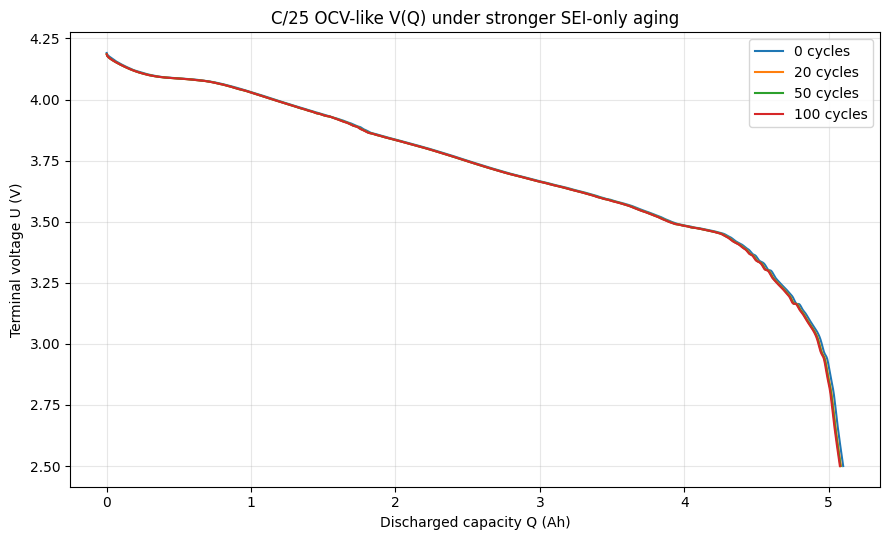

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_c25_VQ_overlay.png


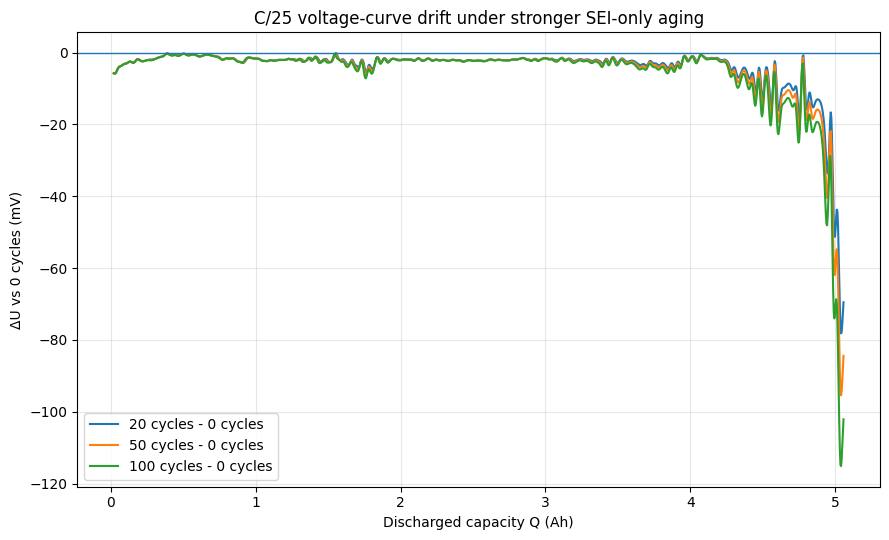

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_c25_deltaU_vs_Q.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_voltage_linkage_audit.csv


,degradation_metric,deltaU_mean_corr,metric_0,metric_100,deltaU_mean_100_mV
0,sei_thickness_m,-0.896718,5.007573e-09,1.866443e-08,-5.626499
1,lli_percent,-0.896718,9.347460e-05,1.686661e-01,-5.626499
2,total_lithium_lost_mol,-0.896718,2.654362e-07,4.789546e-04,-5.626499
3,sei_capacity_loss_Ah,-0.896718,7.114083e-06,1.283669e-02,-5.626499


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,All selected C/25 diagnostic discharge segment...,strong,C/25 diagnostic segments are valid
1,curve_quality,All C/25 V(Q) curves passed quality audit = True,strong,C/25 V(Q) curves are technically comparable
2,voltage_drift,100-cycle mean ΔU = -5.626 mV; p95 |ΔU| = 20.1...,data-backed,C/25 voltage drift is quantifiable
3,monotonicity,Mean ΔU becomes monotonically more negative wi...,strong,C/25 voltage drift follows aging severity
4,linkage,C/25 voltage drift was compared against SEI th...,audit-level,voltage drift can be linked to degradation-sta...
5,overall,C/25 OCV-like V(Q) branch was run at 0/20/50/1...,supported,C/25 V(Q) drift detects stronger SEI-only aging


In [11]:
# Cell 11 — C/25 V(Q) visualization and classification（C/25 V(Q) 可视化与分类）

# Figure 1 — V(Q) overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in c25_curve_table.groupby("cycle"):
    plt.plot(g["Q_dis_Ah"], g["U_V"], label=f"{cycle} cycles")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("Terminal voltage U (V)")
plt.title("C/25 OCV-like V(Q) under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_c25_VQ_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — ΔU(Q) vs 0-cycle
plt.figure(figsize=(9, 5.5))
for cycle, g in c25_voltage_drift_curve.groupby("cycle"):
    if cycle == 0:
        continue
    plt.plot(g["Q_dis_Ah"], g["deltaU_vs_0_mV"], label=f"{cycle} cycles - 0 cycles")
plt.axhline(0, linewidth=1)
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ΔU vs 0 cycles (mV)")
plt.title("C/25 voltage-curve drift under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_c25_deltaU_vs_Q.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Link voltage drift to degradation-state variables
drift_linkage = c25_voltage_drift_audit.merge(
    aging_state_table,
    on="cycle",
    how="left",
)

linkage_rows = []

for metric in ["sei_thickness_m", "lli_percent", "total_lithium_lost_mol", "sei_capacity_loss_Ah"]:
    x = drift_linkage[metric].to_numpy(dtype=float)
    y = drift_linkage["deltaU_mean_mV"].to_numpy(dtype=float)

    if np.isfinite(x).all() and np.isfinite(y).all() and len(x) >= 3:
        corr = float(np.corrcoef(x, y)[0, 1])
    else:
        corr = np.nan

    linkage_rows.append({
        "degradation_metric": metric,
        "deltaU_mean_corr": corr,
        "metric_0": float(drift_linkage.loc[drift_linkage["cycle"] == 0, metric].iloc[0]),
        "metric_100": float(drift_linkage.loc[drift_linkage["cycle"] == 100, metric].iloc[0]),
        "deltaU_mean_100_mV": float(drift_linkage.loc[drift_linkage["cycle"] == 100, "deltaU_mean_mV"].iloc[0]),
    })

c25_voltage_linkage_audit = pd.DataFrame(linkage_rows)

linkage_path = DATA / "stronger_sei_diag_c25_voltage_linkage_audit.csv"
c25_voltage_linkage_audit.to_csv(linkage_path, index=False)

print(f"[OK] saved: {linkage_path}")
display(c25_voltage_linkage_audit)

# Conservative classification
deltaU100_mean = float(c25_voltage_drift_audit.loc[c25_voltage_drift_audit["cycle"] == 100, "deltaU_mean_mV"].iloc[0])
deltaU100_p95 = float(c25_voltage_drift_audit.loc[c25_voltage_drift_audit["cycle"] == 100, "deltaU_p95_abs_mV"].iloc[0])
deltaU100_maxabs = float(c25_voltage_drift_audit.loc[c25_voltage_drift_audit["cycle"] == 100, "deltaU_max_abs_mV"].iloc[0])

# Monotonic direction: because SEI aging usually lowers usable-voltage curve in this setup,
# we check whether deltaU_mean becomes increasingly negative.
delta_means = (
    c25_voltage_drift_audit
    .sort_values("cycle")["deltaU_mean_mV"]
    .to_numpy(dtype=float)
)
mean_drift_monotonic_negative = bool(np.all(np.diff(delta_means) <= 1e-8))

if mean_drift_monotonic_negative and abs(deltaU100_mean) >= 5:
    strength = "supported"
    verdict = "C/25 V(Q) drift detects stronger SEI-only aging"
elif mean_drift_monotonic_negative:
    strength = "partially supported"
    verdict = "C/25 V(Q) drift follows aging severity but remains weak"
else:
    strength = "deferred"
    verdict = "C/25 V(Q) drift is not monotonic; interpretation deferred"

c25_classification_table = pd.DataFrame([
    {
        "metric_layer": "segment_quality",
        "evidence": "All selected C/25 diagnostic discharge segments passed current and duration audit.",
        "strength": "strong",
        "classification": "C/25 diagnostic segments are valid",
    },
    {
        "metric_layer": "curve_quality",
        "evidence": f"All C/25 V(Q) curves passed quality audit = {bool(c25_quality_audit['pass_curve_quality'].all())}",
        "strength": "strong",
        "classification": "C/25 V(Q) curves are technically comparable",
    },
    {
        "metric_layer": "voltage_drift",
        "evidence": f"100-cycle mean ΔU = {deltaU100_mean:.3f} mV; p95 |ΔU| = {deltaU100_p95:.3f} mV; max |ΔU| = {deltaU100_maxabs:.3f} mV.",
        "strength": "data-backed",
        "classification": "C/25 voltage drift is quantifiable",
    },
    {
        "metric_layer": "monotonicity",
        "evidence": f"Mean ΔU becomes monotonically more negative with aging = {mean_drift_monotonic_negative}.",
        "strength": "strong" if mean_drift_monotonic_negative else "insufficient",
        "classification": "C/25 voltage drift follows aging severity" if mean_drift_monotonic_negative else "C/25 voltage drift does not follow aging severity",
    },
    {
        "metric_layer": "linkage",
        "evidence": "C/25 voltage drift was compared against SEI thickness, LLI, lithium loss, and SEI capacity loss.",
        "strength": "audit-level",
        "classification": "voltage drift can be linked to degradation-state metrics, but mechanism uniqueness is not yet proven",
    },
    {
        "metric_layer": "overall",
        "evidence": "C/25 OCV-like V(Q) branch was run at 0/20/50/100-cycle SEI-only checkpoints.",
        "strength": strength,
        "classification": verdict,
    },
])

c25_classification_path = DATA / "stronger_sei_diag_c25_classification_table.csv"
c25_classification_table.to_csv(c25_classification_path, index=False)

print(f"[OK] saved: {c25_classification_path}")
display(c25_classification_table)

In [12]:
# Cell 11A — Central-window C/25 voltage-drift audit（C/25 中央窗口电压漂移审计）

# Endpoint regions can strongly amplify ΔU(Q) because all curves terminate at 2.5 V
# with different Q_end values. This audit separates central-window drift from endpoint drift.

CENTRAL_Q_LO_AH = 0.20
CENTRAL_Q_HI_AH = 4.50

central_drift_rows = []

for cycle in CHECKPOINT_CYCLES:
    g = c25_voltage_drift_curve[
        (c25_voltage_drift_curve["cycle"] == cycle)
        & (c25_voltage_drift_curve["Q_dis_Ah"] >= CENTRAL_Q_LO_AH)
        & (c25_voltage_drift_curve["Q_dis_Ah"] <= CENTRAL_Q_HI_AH)
    ].copy()

    endpoint_g = c25_voltage_drift_curve[
        (c25_voltage_drift_curve["cycle"] == cycle)
        & (c25_voltage_drift_curve["Q_dis_Ah"] > CENTRAL_Q_HI_AH)
    ].copy()

    central_delta = g["deltaU_vs_0_mV"].to_numpy(dtype=float)
    endpoint_delta = endpoint_g["deltaU_vs_0_mV"].to_numpy(dtype=float)

    central_drift_rows.append({
        "cycle": cycle,
        "central_Q_lo_Ah": CENTRAL_Q_LO_AH,
        "central_Q_hi_Ah": CENTRAL_Q_HI_AH,
        "central_n_points": int(len(g)),
        "central_deltaU_mean_mV": float(np.mean(central_delta)),
        "central_deltaU_median_mV": float(np.median(central_delta)),
        "central_deltaU_min_mV": float(np.min(central_delta)),
        "central_deltaU_max_mV": float(np.max(central_delta)),
        "central_deltaU_p95_abs_mV": float(np.percentile(np.abs(central_delta), 95)),
        "central_deltaU_max_abs_mV": float(np.max(np.abs(central_delta))),
        "endpoint_n_points": int(len(endpoint_g)),
        "endpoint_deltaU_mean_mV": float(np.mean(endpoint_delta)) if len(endpoint_delta) else np.nan,
        "endpoint_deltaU_p95_abs_mV": float(np.percentile(np.abs(endpoint_delta), 95)) if len(endpoint_delta) else np.nan,
        "endpoint_deltaU_max_abs_mV": float(np.max(np.abs(endpoint_delta))) if len(endpoint_delta) else np.nan,
    })

c25_central_drift_audit = pd.DataFrame(central_drift_rows)

central_drift_path = DATA / "stronger_sei_diag_c25_central_window_drift_audit.csv"
c25_central_drift_audit.to_csv(central_drift_path, index=False)

print(f"[OK] saved: {central_drift_path}")
display(c25_central_drift_audit)

# Monotonicity of central-window mean drift
central_means = (
    c25_central_drift_audit
    .sort_values("cycle")["central_deltaU_mean_mV"]
    .to_numpy(dtype=float)
)

central_mean_monotonic_negative = bool(np.all(np.diff(central_means) <= 1e-8))

print(f"[CHECK] central-window mean ΔU monotonic negative: {central_mean_monotonic_negative}")

# Compare full-window vs central-window interpretation
comparison_rows = []

for cycle in CHECKPOINT_CYCLES:
    full = c25_voltage_drift_audit[c25_voltage_drift_audit["cycle"] == cycle].iloc[0]
    central = c25_central_drift_audit[c25_central_drift_audit["cycle"] == cycle].iloc[0]

    comparison_rows.append({
        "cycle": cycle,
        "full_mean_deltaU_mV": float(full["deltaU_mean_mV"]),
        "central_mean_deltaU_mV": float(central["central_deltaU_mean_mV"]),
        "full_p95_abs_mV": float(full["deltaU_p95_abs_mV"]),
        "central_p95_abs_mV": float(central["central_deltaU_p95_abs_mV"]),
        "endpoint_p95_abs_mV": float(central["endpoint_deltaU_p95_abs_mV"]),
        "endpoint_amplification_flag": bool(
            central["endpoint_deltaU_p95_abs_mV"] > 2 * max(central["central_deltaU_p95_abs_mV"], 1e-9)
        ),
    })

c25_full_vs_central_audit = pd.DataFrame(comparison_rows)

full_vs_central_path = DATA / "stronger_sei_diag_c25_full_vs_central_audit.csv"
c25_full_vs_central_audit.to_csv(full_vs_central_path, index=False)

print(f"[OK] saved: {full_vs_central_path}")
display(c25_full_vs_central_audit)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_central_window_drift_audit.csv


,cycle,central_Q_lo_Ah,central_Q_hi_Ah,central_n_points,central_deltaU_mean_mV,central_deltaU_median_mV,central_deltaU_min_mV,central_deltaU_max_mV,central_deltaU_p95_abs_mV,central_deltaU_max_abs_mV,endpoint_n_points,endpoint_deltaU_mean_mV,endpoint_deltaU_p95_abs_mV,endpoint_deltaU_max_abs_mV
0,0,0.2,4.5,1024,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,133,0.000000,0.000000,0.000000
1,20,0.2,4.5,1024,-2.257835,-2.039216,-13.066764,-0.126801,4.472989,13.066764,133,-19.085217,65.712479,78.191682
2,50,0.2,4.5,1024,-2.460277,-2.131632,-15.231720,-0.276471,5.203538,15.231720,133,-23.519015,82.489760,95.414751
3,100,0.2,4.5,1024,-2.694278,-2.195469,-17.778598,-0.330701,6.250651,17.778598,133,-28.933494,102.538971,115.119963


[CHECK] central-window mean ΔU monotonic negative: True
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_full_vs_central_audit.csv


,cycle,full_mean_deltaU_mV,central_mean_deltaU_mV,full_p95_abs_mV,central_p95_abs_mV,endpoint_p95_abs_mV,endpoint_amplification_flag
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,False
1,20,-4.160465,-2.257835,13.706564,4.472989,65.712479,True
2,50,-4.825934,-2.460277,16.622546,5.203538,82.489760,True
3,100,-5.626499,-2.694278,20.185535,6.250651,102.538971,True


In [13]:
# Cell 11B — Revised C/25 classification with endpoint-amplification control（带端点放大控制的 C/25 修正分类）

central_100 = c25_central_drift_audit[c25_central_drift_audit["cycle"] == 100].iloc[0]
full_100 = c25_full_vs_central_audit[c25_full_vs_central_audit["cycle"] == 100].iloc[0]

central_mean_100 = float(central_100["central_deltaU_mean_mV"])
central_p95_100 = float(central_100["central_deltaU_p95_abs_mV"])
endpoint_p95_100 = float(central_100["endpoint_deltaU_p95_abs_mV"])
endpoint_flag_100 = bool(full_100["endpoint_amplification_flag"])

central_means = (
    c25_central_drift_audit
    .sort_values("cycle")["central_deltaU_mean_mV"]
    .to_numpy(dtype=float)
)
central_monotonic_negative = bool(np.all(np.diff(central_means) <= 1e-8))

if central_monotonic_negative and abs(central_mean_100) >= 5 and not endpoint_flag_100:
    revised_strength = "supported"
    revised_verdict = "C/25 central-window V(Q) drift robustly detects stronger SEI-only aging"
elif central_monotonic_negative and abs(central_mean_100) >= 2:
    revised_strength = "partially supported"
    revised_verdict = "C/25 V(Q) drift follows aging severity, but the strongest signal is endpoint-amplified"
elif central_monotonic_negative:
    revised_strength = "weakly supported"
    revised_verdict = "C/25 central-window V(Q) drift is monotonic but weak"
else:
    revised_strength = "deferred"
    revised_verdict = "C/25 voltage drift is not monotonic after endpoint control"

c25_revised_classification_table = pd.DataFrame([
    {
        "metric_layer": "segment_quality",
        "evidence": "All selected C/25 diagnostic discharge segments passed current and duration audit.",
        "strength": "strong",
        "classification": "C/25 diagnostic segments are valid",
    },
    {
        "metric_layer": "curve_quality",
        "evidence": f"All C/25 V(Q) curves passed quality audit = {bool(c25_quality_audit['pass_curve_quality'].all())}",
        "strength": "strong",
        "classification": "C/25 V(Q) curves are technically comparable",
    },
    {
        "metric_layer": "central_window_drift",
        "evidence": (
            f"100-cycle central-window mean ΔU = {central_mean_100:.3f} mV; "
            f"central p95 |ΔU| = {central_p95_100:.3f} mV."
        ),
        "strength": "data-backed",
        "classification": "central-window C/25 voltage drift is quantifiable",
    },
    {
        "metric_layer": "central_monotonicity",
        "evidence": f"Central-window mean ΔU becomes monotonically more negative with aging = {central_monotonic_negative}.",
        "strength": "strong" if central_monotonic_negative else "insufficient",
        "classification": "central-window voltage drift follows aging severity" if central_monotonic_negative else "central-window voltage drift does not follow aging severity",
    },
    {
        "metric_layer": "endpoint_amplification",
        "evidence": (
            f"100-cycle endpoint p95 |ΔU| = {endpoint_p95_100:.3f} mV; "
            f"endpoint amplification flag = {endpoint_flag_100}."
        ),
        "strength": "critical boundary",
        "classification": "full-window voltage drift is endpoint-amplified" if endpoint_flag_100 else "endpoint amplification not dominant",
    },
    {
        "metric_layer": "linkage",
        "evidence": "C/25 central/full-window voltage drift was compared against SEI thickness, LLI, lithium loss, and SEI capacity loss.",
        "strength": "audit-level",
        "classification": "voltage drift can be linked to degradation-state metrics, but mechanism uniqueness is not yet proven",
    },
    {
        "metric_layer": "overall",
        "evidence": "C/25 OCV-like V(Q) branch was run at 0/20/50/100-cycle SEI-only checkpoints with endpoint-control audit.",
        "strength": revised_strength,
        "classification": revised_verdict,
    },
])

revised_classification_path = DATA / "stronger_sei_diag_c25_revised_classification_table.csv"
c25_revised_classification_table.to_csv(revised_classification_path, index=False)

print(f"[OK] saved: {revised_classification_path}")
display(c25_revised_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_c25_revised_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,All selected C/25 diagnostic discharge segment...,strong,C/25 diagnostic segments are valid
1,curve_quality,All C/25 V(Q) curves passed quality audit = True,strong,C/25 V(Q) curves are technically comparable
2,central_window_drift,100-cycle central-window mean ΔU = -2.694 mV; ...,data-backed,central-window C/25 voltage drift is quantifiable
3,central_monotonicity,Central-window mean ΔU becomes monotonically m...,strong,central-window voltage drift follows aging sev...
4,endpoint_amplification,100-cycle endpoint p95 |ΔU| = 102.539 mV; endp...,critical boundary,full-window voltage drift is endpoint-amplified
5,linkage,C/25 central/full-window voltage drift was com...,audit-level,voltage drift can be linked to degradation-sta...
6,overall,C/25 OCV-like V(Q) branch was run at 0/20/50/1...,partially supported,"C/25 V(Q) drift follows aging severity, but th..."


In [14]:
# Cell 12 — Stronger-checkpoint GITT-like diagnostic branch runner（增强检查点 GITT-like 诊断分支运行）

GITT_PULSE_RATE = "C/10"
GITT_PULSE_DURATION_MIN = 30
GITT_REST_DURATION_MIN = 60
GITT_N_PULSES = 16

GITT_EXPECTED_CURRENT_A = 0.5
GITT_CURRENT_LO_A = 0.40
GITT_CURRENT_HI_A = 0.60

GITT_PULSE_DURATION_LO_MIN = 25
GITT_PULSE_DURATION_HI_MIN = 35
GITT_REST_DURATION_LO_MIN = 55
GITT_REST_DURATION_HI_MIN = 65


def make_gitt_like_experiment(period="60 seconds"):
    """Build coarse GITT-like pulse-rest diagnostic protocol."""
    steps = []
    for _ in range(GITT_N_PULSES):
        steps.append(f"Discharge at {GITT_PULSE_RATE} for {GITT_PULSE_DURATION_MIN} minutes")
        steps.append(f"Rest for {GITT_REST_DURATION_MIN} minutes")
    return pybamm.Experiment(steps, period=period)


def run_gitt_like_diagnostic(cycle, starting_solution=None):
    """
    Run GITT-like diagnostic branch from a pre-diagnostic aging checkpoint.
    """
    model, pv = build_sei_only_model()
    experiment = make_gitt_like_experiment(period="60 seconds")

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] GITT-like diagnostic branch: cycle={cycle}")
    sol = sim.solve(**kwargs)
    print(f"[OK] solved: cycle={cycle}")
    return sol


stronger_gitt_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    stronger_gitt_solutions[cycle] = run_gitt_like_diagnostic(
        cycle=cycle,
        starting_solution=checkpoint_solutions[cycle],
    )

print("[OK] All stronger-checkpoint GITT-like diagnostic branches solved.")
print("[N solutions]", len(stronger_gitt_solutions))

[RUN] GITT-like diagnostic branch: cycle=0
[OK] solved: cycle=0
[RUN] GITT-like diagnostic branch: cycle=20
[OK] solved: cycle=20
[RUN] GITT-like diagnostic branch: cycle=50
[OK] solved: cycle=50
[RUN] GITT-like diagnostic branch: cycle=100
[OK] solved: cycle=100
[OK] All stronger-checkpoint GITT-like diagnostic branches solved.
[N solutions] 4


In [15]:
# Cell 13 — Stronger-checkpoint GITT-like segment audit and reconstruction points（增强检查点 GITT-like 分段审计与重构点）

gitt_all_segments = []
gitt_selected_rows = []

for cycle, sol in stronger_gitt_solutions.items():
    seg = summarize_current_segments(sol, cycle)
    gitt_all_segments.append(seg)

    pulse_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(GITT_CURRENT_LO_A, GITT_CURRENT_HI_A))
        & (seg["duration_min"].between(GITT_PULSE_DURATION_LO_MIN, GITT_PULSE_DURATION_HI_MIN))
    ].copy()

    if len(pulse_candidates) < GITT_N_PULSES:
        raise RuntimeError(
            f"Not enough GITT-like pulse candidates for cycle={cycle}: "
            f"found {len(pulse_candidates)}, expected {GITT_N_PULSES}"
        )

    selected_pulses = pulse_candidates.sort_values("t_start_s").tail(GITT_N_PULSES)

    for pulse_order, (_, pulse_row) in enumerate(selected_pulses.iterrows(), start=1):
        pulse_seg_id = int(pulse_row["segment_id"])

        rest = seg[
            (seg["segment_id"] > pulse_seg_id)
            & (seg["segment_type"] == "rest")
            & (seg["duration_min"].between(GITT_REST_DURATION_LO_MIN, GITT_REST_DURATION_HI_MIN))
        ].sort_values("segment_id").head(1)

        if rest.empty:
            raise RuntimeError(f"No matching rest segment after pulse {pulse_seg_id} for cycle={cycle}")

        rest_row = rest.iloc[0]

        gitt_selected_rows.append({
            "cycle": cycle,
            "pulse_order": pulse_order,
            "pulse_segment_id": pulse_seg_id,
            "rest_segment_id": int(rest_row["segment_id"]),
            "pulse_idx_start": int(pulse_row["idx_start"]),
            "pulse_idx_stop": int(pulse_row["idx_stop"]),
            "rest_idx_start": int(rest_row["idx_start"]),
            "rest_idx_stop": int(rest_row["idx_stop"]),
            "pulse_duration_min": float(pulse_row["duration_min"]),
            "rest_duration_min": float(rest_row["duration_min"]),
            "pulse_I_mean_A": float(pulse_row["I_mean_A"]),
            "U_pulse_start_V": float(pulse_row["U_start_V"]),
            "U_pulse_end_V": float(pulse_row["U_end_V"]),
            "U_rest_start_V": float(rest_row["U_start_V"]),
            "U_rest_end_V": float(rest_row["U_end_V"]),
        })

stronger_gitt_segment_audit = pd.concat(gitt_all_segments, ignore_index=True)
stronger_gitt_selected_sequence_audit = pd.DataFrame(gitt_selected_rows)

segment_path = DATA / "stronger_sei_diag_gitt_segment_audit.csv"
selected_path = DATA / "stronger_sei_diag_gitt_selected_sequence_audit.csv"

stronger_gitt_segment_audit.to_csv(segment_path, index=False)
stronger_gitt_selected_sequence_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(stronger_gitt_selected_sequence_audit.groupby("cycle").agg(
    n_pulses=("pulse_order", "count"),
    pulse_I_mean_A=("pulse_I_mean_A", "mean"),
    pulse_duration_mean_min=("pulse_duration_min", "mean"),
    rest_duration_mean_min=("rest_duration_min", "mean"),
    U_first_rest_end_V=("U_rest_end_V", "first"),
    U_last_rest_end_V=("U_rest_end_V", "last"),
))

assert stronger_gitt_selected_sequence_audit.groupby("cycle")["pulse_order"].count().eq(GITT_N_PULSES).all()


def integrate_segment_charge_Ah(sol, idx_start, idx_stop):
    """Integrate positive discharge current over selected segment."""
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    if len(t) < 2:
        return 0.0

    t_rel_h = (t - t[0]) / 3600.0
    dt_h = np.diff(t_rel_h)
    i_mid = 0.5 * (i[1:] + i[:-1])
    return float(np.sum(i_mid * dt_h))


point_rows = []

for cycle, sol in stronger_gitt_solutions.items():
    selected = stronger_gitt_selected_sequence_audit[
        stronger_gitt_selected_sequence_audit["cycle"] == cycle
    ].copy()
    selected = selected.sort_values("pulse_order").reset_index(drop=True)

    cumulative_Q_Ah = 0.0

    for _, row in selected.iterrows():
        pulse_Q_Ah = integrate_segment_charge_Ah(
            sol=sol,
            idx_start=int(row["pulse_idx_start"]),
            idx_stop=int(row["pulse_idx_stop"]),
        )

        cumulative_Q_Ah += pulse_Q_Ah

        point_rows.append({
            "cycle": int(cycle),
            "pulse_order": int(row["pulse_order"]),
            "pulse_Q_Ah": pulse_Q_Ah,
            "Q_cumulative_Ah": cumulative_Q_Ah,
            "U_pulse_start_V": float(row["U_pulse_start_V"]),
            "U_pulse_end_V": float(row["U_pulse_end_V"]),
            "U_rest_start_V": float(row["U_rest_start_V"]),
            "U_rest_end_V": float(row["U_rest_end_V"]),
            "U_finite_rest_ocv_like_V": float(row["U_rest_end_V"]),
            "pulse_drop_mV": float((row["U_pulse_start_V"] - row["U_pulse_end_V"]) * 1000),
            "rest_recovery_mV": float((row["U_rest_end_V"] - row["U_rest_start_V"]) * 1000),
            "net_relax_from_pulse_end_mV": float((row["U_rest_end_V"] - row["U_pulse_end_V"]) * 1000),
            "pulse_duration_min": float(row["pulse_duration_min"]),
            "rest_duration_min": float(row["rest_duration_min"]),
            "pulse_I_mean_A": float(row["pulse_I_mean_A"]),
        })

stronger_gitt_points = pd.DataFrame(point_rows)

point_path = DATA / "stronger_sei_diag_gitt_reconstruction_point_table.csv"
stronger_gitt_points.to_csv(point_path, index=False)

print(f"[OK] saved: {point_path}")
display(stronger_gitt_points.groupby("cycle").agg(
    n_points=("pulse_order", "count"),
    Q_end_Ah=("Q_cumulative_Ah", "max"),
    U_first_rest_end_V=("U_finite_rest_ocv_like_V", "first"),
    U_last_rest_end_V=("U_finite_rest_ocv_like_V", "last"),
    mean_pulse_Q_Ah=("pulse_Q_Ah", "mean"),
    mean_rest_recovery_mV=("rest_recovery_mV", "mean"),
))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_selected_sequence_audit.csv


,n_pulses,pulse_I_mean_A,pulse_duration_mean_min,rest_duration_mean_min,U_first_rest_end_V,U_last_rest_end_V
cycle,,,,,,
0,16,0.5,30.0,60.0,4.122518,3.496030
20,16,0.5,30.0,60.0,4.120221,3.494346
50,16,0.5,30.0,60.0,4.120205,3.494323
100,16,0.5,30.0,60.0,4.120279,3.494310


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_reconstruction_point_table.csv


,n_points,Q_end_Ah,U_first_rest_end_V,U_last_rest_end_V,mean_pulse_Q_Ah,mean_rest_recovery_mV
cycle,,,,,,
0,16,4.0,4.122518,3.496030,0.25,12.089298
20,16,4.0,4.120221,3.494346,0.25,11.974609
50,16,4.0,4.120205,3.494323,0.25,11.950841
100,16,4.0,4.120279,3.494310,0.25,11.907672


In [16]:
# Cell 14 — Stronger-checkpoint GITT-like quality and drift audit（增强检查点 GITT-like 质量与漂移审计）

gitt_quality_rows = []

for cycle, g in stronger_gitt_points.groupby("cycle"):
    g = g.sort_values("pulse_order").reset_index(drop=True)

    q = g["Q_cumulative_Ah"].to_numpy(dtype=float)
    u = g["U_finite_rest_ocv_like_V"].to_numpy(dtype=float)
    recovery = g["rest_recovery_mV"].to_numpy(dtype=float)
    pulse_q = g["pulse_Q_Ah"].to_numpy(dtype=float)

    dQ = np.diff(q)
    dU = np.diff(u)

    n_points = len(g)
    q_end = float(q[-1])
    voltage_span = float(u[0] - u[-1])
    q_nonmono = int(np.sum(dQ <= 0))
    u_increase_count = int(np.sum(dU > 1e-5))
    u_increase_fraction = u_increase_count / max(len(dU), 1)

    pulse_Q_mean = float(np.mean(pulse_q))
    pulse_Q_cv_pct = float(np.std(pulse_q) / pulse_Q_mean * 100) if pulse_Q_mean != 0 else np.nan

    recovery_positive_fraction = float(np.mean(recovery > 0))

    pass_quality = (
        n_points == GITT_N_PULSES
        and q_end >= 3.9
        and voltage_span > 0.5
        and q_nonmono == 0
        and u_increase_fraction == 0
        and pulse_Q_cv_pct < 1.0
        and recovery_positive_fraction > 0.9
    )

    gitt_quality_rows.append({
        "cycle": int(cycle),
        "n_points": n_points,
        "Q_end_Ah": q_end,
        "U_first_rest_end_V": float(u[0]),
        "U_last_rest_end_V": float(u[-1]),
        "voltage_span_V": voltage_span,
        "Q_nonmonotonic_count": q_nonmono,
        "U_rest_end_increase_count": u_increase_count,
        "U_rest_end_increase_fraction": u_increase_fraction,
        "pulse_Q_mean_Ah": pulse_Q_mean,
        "pulse_Q_cv_pct": pulse_Q_cv_pct,
        "rest_recovery_positive_fraction": recovery_positive_fraction,
        "rest_recovery_mean_mV": float(np.mean(recovery)),
        "rest_recovery_min_mV": float(np.min(recovery)),
        "rest_recovery_max_mV": float(np.max(recovery)),
        "pass_reconstruction_quality": pass_quality,
    })

stronger_gitt_quality_audit = pd.DataFrame(gitt_quality_rows)

quality_path = DATA / "stronger_sei_diag_gitt_quality_audit.csv"
stronger_gitt_quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(stronger_gitt_quality_audit)

assert stronger_gitt_quality_audit["pass_reconstruction_quality"].all(), (
    "At least one GITT-like reconstruction failed quality audit."
)

# Compare all checkpoints against 0-cycle reference by pulse_order
base = stronger_gitt_points[stronger_gitt_points["cycle"] == 0].sort_values("pulse_order").reset_index(drop=True)

comparison_rows = []

for cycle, g in stronger_gitt_points.groupby("cycle"):
    g = g.sort_values("pulse_order").reset_index(drop=True)

    if len(g) != len(base):
        raise RuntimeError(f"Pulse count mismatch for cycle={cycle}")

    deltaU_mV = (
        g["U_finite_rest_ocv_like_V"].to_numpy(dtype=float)
        - base["U_finite_rest_ocv_like_V"].to_numpy(dtype=float)
    ) * 1000

    delta_recovery_mV = (
        g["rest_recovery_mV"].to_numpy(dtype=float)
        - base["rest_recovery_mV"].to_numpy(dtype=float)
    )

    for idx in range(len(g)):
        comparison_rows.append({
            "cycle": int(cycle),
            "pulse_order": int(g.loc[idx, "pulse_order"]),
            "Q_cumulative_Ah": float(g.loc[idx, "Q_cumulative_Ah"]),
            "U_cycle_V": float(g.loc[idx, "U_finite_rest_ocv_like_V"]),
            "U_0cycle_V": float(base.loc[idx, "U_finite_rest_ocv_like_V"]),
            "deltaU_vs_0_mV": float(deltaU_mV[idx]),
            "recovery_cycle_mV": float(g.loc[idx, "rest_recovery_mV"]),
            "recovery_0cycle_mV": float(base.loc[idx, "rest_recovery_mV"]),
            "delta_recovery_vs_0_mV": float(delta_recovery_mV[idx]),
        })

stronger_gitt_comparison = pd.DataFrame(comparison_rows)

comparison_path = DATA / "stronger_sei_diag_gitt_comparison_table.csv"
stronger_gitt_comparison.to_csv(comparison_path, index=False)

print(f"[OK] saved: {comparison_path}")
display(stronger_gitt_comparison.head())

# Drift summary by cycle
gitt_drift_rows = []

for cycle, g in stronger_gitt_comparison.groupby("cycle"):
    delta = g["deltaU_vs_0_mV"].to_numpy(dtype=float)
    rec_delta = g["delta_recovery_vs_0_mV"].to_numpy(dtype=float)

    gitt_drift_rows.append({
        "cycle": int(cycle),
        "deltaU_mean_mV": float(np.mean(delta)),
        "deltaU_median_mV": float(np.median(delta)),
        "deltaU_min_mV": float(np.min(delta)),
        "deltaU_max_mV": float(np.max(delta)),
        "deltaU_p95_abs_mV": float(np.percentile(np.abs(delta), 95)),
        "deltaU_max_abs_mV": float(np.max(np.abs(delta))),
        "delta_recovery_mean_mV": float(np.mean(rec_delta)),
        "delta_recovery_median_mV": float(np.median(rec_delta)),
        "delta_recovery_max_abs_mV": float(np.max(np.abs(rec_delta))),
    })

stronger_gitt_drift_audit = pd.DataFrame(gitt_drift_rows)

drift_path = DATA / "stronger_sei_diag_gitt_drift_audit.csv"
stronger_gitt_drift_audit.to_csv(drift_path, index=False)

print(f"[OK] saved: {drift_path}")
display(stronger_gitt_drift_audit)

# Monotonicity checks
gitt_mean_delta = stronger_gitt_drift_audit.sort_values("cycle")["deltaU_mean_mV"].to_numpy(dtype=float)
gitt_drift_monotonic_negative = bool(np.all(np.diff(gitt_mean_delta) <= 1e-8))

print(f"[CHECK] GITT-like mean ΔU monotonic negative: {gitt_drift_monotonic_negative}")
print("[OK] GITT-like quality and drift audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_quality_audit.csv


,cycle,n_points,Q_end_Ah,U_first_rest_end_V,U_last_rest_end_V,voltage_span_V,Q_nonmonotonic_count,U_rest_end_increase_count,U_rest_end_increase_fraction,pulse_Q_mean_Ah,pulse_Q_cv_pct,rest_recovery_positive_fraction,rest_recovery_mean_mV,rest_recovery_min_mV,rest_recovery_max_mV,pass_reconstruction_quality
0,0,16,4.0,4.122518,3.496030,0.626488,0,0,0.0,0.25,2.470714e-13,1.0,12.089298,5.773291,14.815664,True
1,20,16,4.0,4.120221,3.494346,0.625874,0,0,0.0,0.25,1.265338e-12,1.0,11.974609,5.952118,14.919973,True
2,50,16,4.0,4.120205,3.494323,0.625882,0,0,0.0,0.25,0.000000e+00,1.0,11.950841,5.976190,14.891830,True
3,100,16,4.0,4.120279,3.494310,0.625969,0,0,0.0,0.25,0.000000e+00,1.0,11.907672,6.041047,14.860399,True


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_comparison_table.csv


,cycle,pulse_order,Q_cumulative_Ah,U_cycle_V,U_0cycle_V,deltaU_vs_0_mV,recovery_cycle_mV,recovery_0cycle_mV,delta_recovery_vs_0_mV
0,0,1,0.25,4.122518,4.122518,0.0,13.394124,13.394124,0.0
1,0,2,0.50,4.096251,4.096251,0.0,5.773291,5.773291,0.0
2,0,3,0.75,4.081054,4.081054,0.0,10.597576,10.597576,0.0
3,0,4,1.00,4.043031,4.043031,0.0,14.632500,14.632500,0.0
4,0,5,1.25,3.996276,3.996276,0.0,14.765728,14.765728,0.0


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_drift_audit.csv


,cycle,deltaU_mean_mV,deltaU_median_mV,deltaU_min_mV,deltaU_max_mV,deltaU_p95_abs_mV,deltaU_max_abs_mV,delta_recovery_mean_mV,delta_recovery_median_mV,delta_recovery_max_abs_mV
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,20,-1.973657,-2.053688,-3.024807,-0.067764,3.003190,3.024807,-0.114689,-0.133400,0.629678
2,50,-2.124854,-2.099950,-3.559647,-0.075142,3.445075,3.559647,-0.138457,-0.177969,0.768907
3,100,-2.280039,-2.108744,-4.938867,-0.085972,4.144639,4.938867,-0.181626,-0.192377,0.877784


[CHECK] GITT-like mean ΔU monotonic negative: True
[OK] GITT-like quality and drift audit complete.


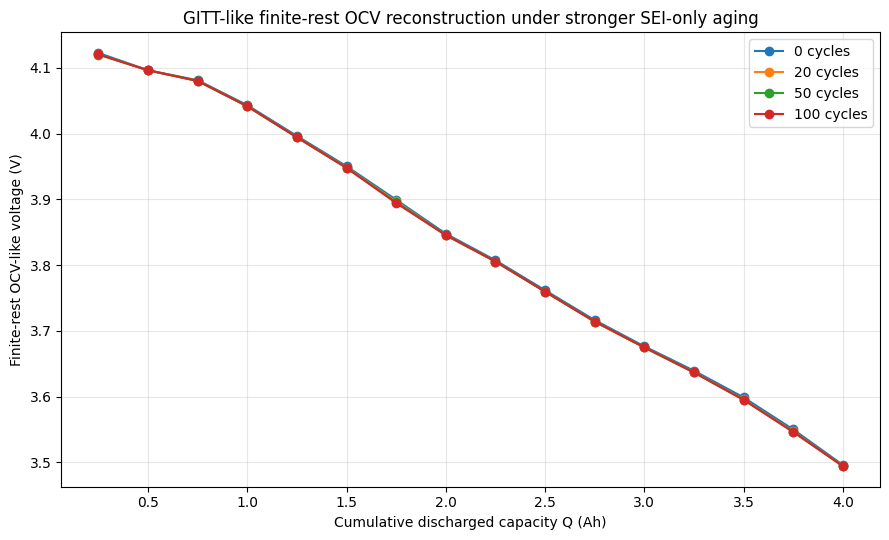

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_gitt_reconstruction_overlay.png


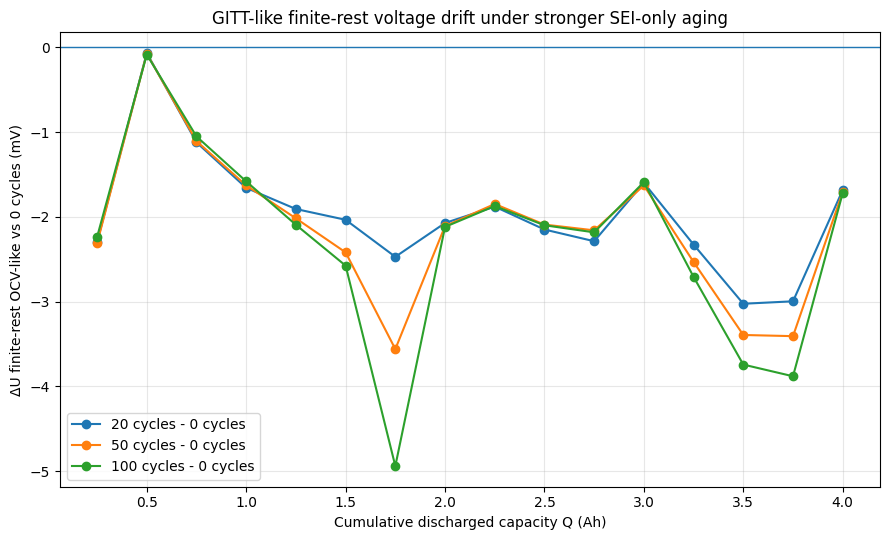

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_gitt_deltaU_vs_Q.png


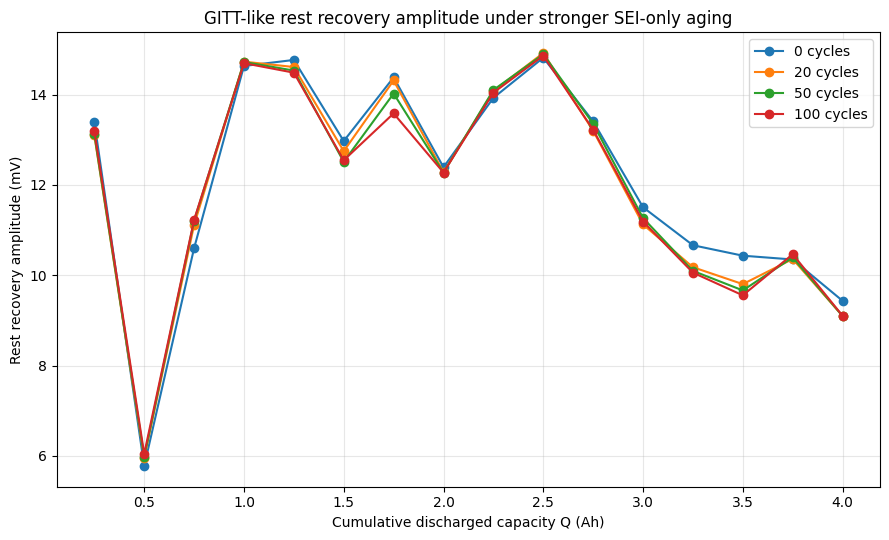

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_diag_gitt_recovery_amplitude.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_linkage_audit.csv


,degradation_metric,deltaU_mean_corr,metric_0,metric_100,deltaU_mean_100_mV
0,sei_thickness_m,-0.834925,5.007573e-09,1.866443e-08,-2.280039
1,lli_percent,-0.834925,9.347460e-05,1.686661e-01,-2.280039
2,total_lithium_lost_mol,-0.834925,2.654362e-07,4.789546e-04,-2.280039
3,sei_capacity_loss_Ah,-0.834925,7.114083e-06,1.283669e-02,-2.280039


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_gitt_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,Each checkpoint produced 16 valid C/10 pulse-r...,strong,GITT-like pulse-rest segmentation is technical...
1,reconstruction_quality,All GITT-like reconstruction quality checks pa...,strong,finite-rest OCV-like points are smooth and mon...
2,voltage_drift,100-cycle mean ΔU = -2.280 mV; p95 |ΔU| = 4.14...,data-backed,GITT-like finite-rest voltage drift is quantif...
3,monotonicity,Mean finite-rest ΔU becomes monotonically more...,strong,GITT-like voltage drift follows aging severity
4,recovery_amplitude,100-cycle mean recovery-amplitude shift = -0.1...,audit-level,rest recovery amplitude remains an auxiliary r...
5,linkage,GITT-like finite-rest voltage drift was compar...,audit-level,finite-rest voltage drift can be linked to deg...
6,overall,GITT-like finite-rest reconstruction was run a...,partially supported,GITT-like finite-rest voltage drift follows ag...


In [17]:
# Cell 15 — Stronger-checkpoint GITT-like visualization and classification（增强检查点 GITT-like 图像与分类）

# Figure 1 — finite-rest OCV-like reconstruction overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in stronger_gitt_points.groupby("cycle"):
    plt.plot(
        g["Q_cumulative_Ah"],
        g["U_finite_rest_ocv_like_V"],
        marker="o",
        label=f"{cycle} cycles"
    )
plt.xlabel("Cumulative discharged capacity Q (Ah)")
plt.ylabel("Finite-rest OCV-like voltage (V)")
plt.title("GITT-like finite-rest OCV reconstruction under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_gitt_reconstruction_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — finite-rest voltage drift vs 0-cycle
plt.figure(figsize=(9, 5.5))
for cycle, g in stronger_gitt_comparison.groupby("cycle"):
    if cycle == 0:
        continue
    plt.plot(
        g["Q_cumulative_Ah"],
        g["deltaU_vs_0_mV"],
        marker="o",
        label=f"{cycle} cycles - 0 cycles"
    )
plt.axhline(0, linewidth=1)
plt.xlabel("Cumulative discharged capacity Q (Ah)")
plt.ylabel("ΔU finite-rest OCV-like vs 0 cycles (mV)")
plt.title("GITT-like finite-rest voltage drift under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_gitt_deltaU_vs_Q.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — recovery amplitude
plt.figure(figsize=(9, 5.5))
for cycle, g in stronger_gitt_points.groupby("cycle"):
    plt.plot(
        g["Q_cumulative_Ah"],
        g["rest_recovery_mV"],
        marker="o",
        label=f"{cycle} cycles"
    )
plt.xlabel("Cumulative discharged capacity Q (Ah)")
plt.ylabel("Rest recovery amplitude (mV)")
plt.title("GITT-like rest recovery amplitude under stronger SEI-only aging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_diag_gitt_recovery_amplitude.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Link GITT-like voltage drift to degradation-state variables
gitt_linkage = stronger_gitt_drift_audit.merge(
    aging_state_table,
    on="cycle",
    how="left",
)

gitt_linkage_rows = []

for metric in ["sei_thickness_m", "lli_percent", "total_lithium_lost_mol", "sei_capacity_loss_Ah"]:
    x = gitt_linkage[metric].to_numpy(dtype=float)
    y = gitt_linkage["deltaU_mean_mV"].to_numpy(dtype=float)

    if np.isfinite(x).all() and np.isfinite(y).all() and len(x) >= 3:
        corr = float(np.corrcoef(x, y)[0, 1])
    else:
        corr = np.nan

    gitt_linkage_rows.append({
        "degradation_metric": metric,
        "deltaU_mean_corr": corr,
        "metric_0": float(gitt_linkage.loc[gitt_linkage["cycle"] == 0, metric].iloc[0]),
        "metric_100": float(gitt_linkage.loc[gitt_linkage["cycle"] == 100, metric].iloc[0]),
        "deltaU_mean_100_mV": float(gitt_linkage.loc[gitt_linkage["cycle"] == 100, "deltaU_mean_mV"].iloc[0]),
    })

stronger_gitt_linkage_audit = pd.DataFrame(gitt_linkage_rows)

linkage_path = DATA / "stronger_sei_diag_gitt_linkage_audit.csv"
stronger_gitt_linkage_audit.to_csv(linkage_path, index=False)

print(f"[OK] saved: {linkage_path}")
display(stronger_gitt_linkage_audit)

# Conservative classification
gitt_100 = stronger_gitt_drift_audit[stronger_gitt_drift_audit["cycle"] == 100].iloc[0]

gitt_mean_100 = float(gitt_100["deltaU_mean_mV"])
gitt_p95_100 = float(gitt_100["deltaU_p95_abs_mV"])
gitt_recovery_shift_100 = float(gitt_100["delta_recovery_mean_mV"])

gitt_mean_delta = stronger_gitt_drift_audit.sort_values("cycle")["deltaU_mean_mV"].to_numpy(dtype=float)
gitt_drift_monotonic_negative = bool(np.all(np.diff(gitt_mean_delta) <= 1e-8))

if gitt_drift_monotonic_negative and abs(gitt_mean_100) >= 5:
    gitt_strength = "supported"
    gitt_verdict = "GITT-like finite-rest voltage drift robustly detects stronger SEI-only aging"
elif gitt_drift_monotonic_negative and abs(gitt_mean_100) >= 2:
    gitt_strength = "partially supported"
    gitt_verdict = "GITT-like finite-rest voltage drift follows aging severity but remains weak"
elif abs(gitt_mean_100) >= 1:
    gitt_strength = "weakly supported"
    gitt_verdict = "GITT-like finite-rest voltage drift is quantifiable but not strictly monotonic"
else:
    gitt_strength = "deferred"
    gitt_verdict = "GITT-like finite-rest voltage drift remains too weak for aging-sensitive classification"

stronger_gitt_classification_table = pd.DataFrame([
    {
        "metric_layer": "segment_quality",
        "evidence": f"Each checkpoint produced {GITT_N_PULSES} valid C/10 pulse-rest pairs.",
        "strength": "strong",
        "classification": "GITT-like pulse-rest segmentation is technically clean",
    },
    {
        "metric_layer": "reconstruction_quality",
        "evidence": f"All GITT-like reconstruction quality checks passed = {bool(stronger_gitt_quality_audit['pass_reconstruction_quality'].all())}",
        "strength": "strong",
        "classification": "finite-rest OCV-like points are smooth and monotonic",
    },
    {
        "metric_layer": "voltage_drift",
        "evidence": (
            f"100-cycle mean ΔU = {gitt_mean_100:.3f} mV; "
            f"p95 |ΔU| = {gitt_p95_100:.3f} mV."
        ),
        "strength": "data-backed",
        "classification": "GITT-like finite-rest voltage drift is quantifiable",
    },
    {
        "metric_layer": "monotonicity",
        "evidence": f"Mean finite-rest ΔU becomes monotonically more negative with aging = {gitt_drift_monotonic_negative}.",
        "strength": "strong" if gitt_drift_monotonic_negative else "limited",
        "classification": "GITT-like voltage drift follows aging severity" if gitt_drift_monotonic_negative else "GITT-like voltage drift does not strictly follow aging severity",
    },
    {
        "metric_layer": "recovery_amplitude",
        "evidence": f"100-cycle mean recovery-amplitude shift = {gitt_recovery_shift_100:.3f} mV.",
        "strength": "audit-level",
        "classification": "rest recovery amplitude remains an auxiliary relaxation descriptor",
    },
    {
        "metric_layer": "linkage",
        "evidence": "GITT-like finite-rest voltage drift was compared against SEI thickness, LLI, lithium loss, and SEI capacity loss.",
        "strength": "audit-level",
        "classification": "finite-rest voltage drift can be linked to degradation-state metrics, but mechanism uniqueness is not yet proven",
    },
    {
        "metric_layer": "overall",
        "evidence": "GITT-like finite-rest reconstruction was run at 0/20/50/100-cycle SEI-only checkpoints.",
        "strength": gitt_strength,
        "classification": gitt_verdict,
    },
])

gitt_classification_path = DATA / "stronger_sei_diag_gitt_classification_table.csv"
stronger_gitt_classification_table.to_csv(gitt_classification_path, index=False)

print(f"[OK] saved: {gitt_classification_path}")
display(stronger_gitt_classification_table)

In [18]:
# Cell 16 — Notebook 21 output inventory audit（Notebook 21 输出文件清单审计）

expected_outputs = [
    DATA / "stronger_sei_diag_aging_state_table.csv",

    DATA / "stronger_sei_diag_capacity_segment_audit.csv",
    DATA / "stronger_sei_diag_capacity_selected_segment_audit.csv",
    DATA / "stronger_sei_diag_capacity_rpt_table.csv",
    DATA / "stronger_sei_diag_capacity_linkage_audit.csv",
    DATA / "stronger_sei_diag_capacity_classification_table.csv",
    FIGURES / "stronger_sei_diag_capacity_retention.png",
    FIGURES / "stronger_sei_diag_capacity_vs_degradation.png",

    DATA / "stronger_sei_diag_c25_segment_audit.csv",
    DATA / "stronger_sei_diag_c25_selected_segment_audit.csv",
    DATA / "stronger_sei_diag_c25_curve_table.csv",
    DATA / "stronger_sei_diag_c25_curve_summary.csv",
    DATA / "stronger_sei_diag_c25_quality_audit.csv",
    DATA / "stronger_sei_diag_c25_voltage_drift_audit.csv",
    DATA / "stronger_sei_diag_c25_voltage_drift_curve.csv",
    DATA / "stronger_sei_diag_c25_voltage_linkage_audit.csv",
    DATA / "stronger_sei_diag_c25_central_window_drift_audit.csv",
    DATA / "stronger_sei_diag_c25_full_vs_central_audit.csv",
    DATA / "stronger_sei_diag_c25_revised_classification_table.csv",
    FIGURES / "stronger_sei_diag_c25_VQ_overlay.png",
    FIGURES / "stronger_sei_diag_c25_deltaU_vs_Q.png",

    DATA / "stronger_sei_diag_gitt_segment_audit.csv",
    DATA / "stronger_sei_diag_gitt_selected_sequence_audit.csv",
    DATA / "stronger_sei_diag_gitt_reconstruction_point_table.csv",
    DATA / "stronger_sei_diag_gitt_quality_audit.csv",
    DATA / "stronger_sei_diag_gitt_comparison_table.csv",
    DATA / "stronger_sei_diag_gitt_drift_audit.csv",
    DATA / "stronger_sei_diag_gitt_linkage_audit.csv",
    DATA / "stronger_sei_diag_gitt_classification_table.csv",
    FIGURES / "stronger_sei_diag_gitt_reconstruction_overlay.png",
    FIGURES / "stronger_sei_diag_gitt_deltaU_vs_Q.png",
    FIGURES / "stronger_sei_diag_gitt_recovery_amplitude.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "stronger_sei_diag_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected Notebook 21 output files are missing."
print("[OK] All expected Notebook 21 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_diag_output_inventory.csv


,path,exists,size_kB
0,data/stronger_sei_diag_aging_state_table.csv,True,1.04
1,data/stronger_sei_diag_capacity_segment_audit.csv,True,102.85
2,data/stronger_sei_diag_capacity_selected_segme...,True,1.16
3,data/stronger_sei_diag_capacity_rpt_table.csv,True,0.73
4,data/stronger_sei_diag_capacity_linkage_audit.csv,True,0.47
5,data/stronger_sei_diag_capacity_classification...,True,0.76
6,figures/stronger_sei_diag_capacity_retention.png,True,127.35
7,figures/stronger_sei_diag_capacity_vs_degradat...,True,131.13
8,data/stronger_sei_diag_c25_segment_audit.csv,True,102.87
9,data/stronger_sei_diag_c25_selected_segment_au...,True,1.20


[OK] All expected Notebook 21 outputs exist.


## Final closure — Notebook 21

### Key findings

Notebook 21 audited whether the stronger SEI-only aging checkpoints established in Notebook 20 produce clearer downstream diagnostic observables.

The diagnostic branches were evaluated at four SEI-only aging checkpoints:

- 0 cycles,
- 20 cycles,
- 50 cycles,
- 100 cycles.

The degradation mechanism remained unchanged:

- OKane2022 parameter set,
- solvent-diffusion-limited SEI,
- lithium plating disabled,
- LAM disabled,
- particle mechanics disabled,
- SEI porosity change disabled,
- isothermal model.

Three diagnostic layers were audited:

1. capacity RPT / external capacity check,
2. C/25 OCV-like V(Q),
3. GITT-like finite-rest OCV reconstruction.

### Phase A — Capacity RPT

The C/3 capacity RPT branch was technically valid at all checkpoints. The selected discharge segments passed the current and duration audit.

The external discharge capacity decreased monotonically with aging:

- 0 cycles: 5.049518 Ah,
- 20 cycles: 5.033878 Ah,
- 50 cycles: 5.030167 Ah,
- 100 cycles: 5.025803 Ah.

At 100 cycles, the external capacity fade was approximately 0.4696%, corresponding to a capacity loss of approximately 0.023715 Ah relative to the 0-cycle reference.

Capacity loss correlated strongly with SEI-state degradation metrics, with correlation coefficients of approximately 0.93 against SEI thickness, LLI, total lithium lost, and SEI capacity loss.

The capacity RPT branch is therefore classified as:

`capacity RPT detects stronger SEI-only aging = supported`

This does not mean the capacity loss is a direct one-to-one readout of SEI capacity loss. The external capacity loss includes SEI/LLI effects as well as voltage-boundary and usable-capacity effects under the 2.5 V cutoff.

### Phase B — C/25 OCV-like V(Q)

The C/25 OCV-like diagnostic branch was technically valid at all checkpoints. All selected C/25 discharge segments passed the current and duration audit, and all V(Q) curves passed the quality audit.

The C/25 discharge capacity decreased monotonically:

- 0 cycles: 5.100618 Ah,
- 20 cycles: 5.085432 Ah,
- 50 cycles: 5.081950 Ah,
- 100 cycles: 5.077778 Ah.

The full-window voltage drift relative to the 0-cycle reference became more negative with aging. At 100 cycles:

- full-window mean ΔU ≈ −5.626 mV,
- full-window p95 |ΔU| ≈ 20.186 mV,
- full-window max |ΔU| ≈ 115.120 mV.

However, the central-window audit showed that the strongest full-window drift is dominated by low-voltage endpoint amplification.

For the central window Q = 0.20–4.50 Ah, the 100-cycle drift was:

- central-window mean ΔU ≈ −2.694 mV,
- central-window median ΔU ≈ −2.195 mV,
- central-window p95 |ΔU| ≈ 6.251 mV.

The endpoint region was much larger:

- endpoint mean ΔU ≈ −28.933 mV,
- endpoint p95 |ΔU| ≈ 102.539 mV,
- endpoint max |ΔU| ≈ 115.120 mV.

The endpoint-amplification flag was true for 20, 50, and 100 cycles.

The revised C/25 classification is therefore:

`C/25 V(Q) drift = partially supported / endpoint-amplified`

C/25 V(Q) follows aging severity, but the strongest signal is concentrated near the low-voltage cutoff. The central-window drift is monotonic but moderate.

### Phase C — GITT-like finite-rest OCV reconstruction

The GITT-like diagnostic branch was technically valid at all checkpoints. Each checkpoint produced 16 valid C/10 pulse-rest pairs with:

- pulse current ≈ 0.5 A,
- pulse duration = 30 min,
- rest duration = 60 min,
- cumulative reconstructed Q-window = 4.0 Ah.

The finite-rest reconstruction quality audit passed at all checkpoints. The reconstructed rest-end voltages were smooth and monotonic, Q increased strictly, pulse charge was consistent, and all rest recovery amplitudes remained positive.

The GITT-like finite-rest voltage drift relative to the 0-cycle reference became more negative with aging:

- 20 cycles: mean ΔU ≈ −1.974 mV,
- 50 cycles: mean ΔU ≈ −2.125 mV,
- 100 cycles: mean ΔU ≈ −2.280 mV.

At 100 cycles:

- mean ΔU ≈ −2.280 mV,
- median ΔU ≈ −2.109 mV,
- p95 |ΔU| ≈ 4.145 mV,
- max |ΔU| ≈ 4.939 mV.

The GITT-like drift is much weaker than the C/25 endpoint-amplified full-window drift, but it is smoother and less dominated by cutoff artifacts.

Rest recovery amplitude remained an auxiliary descriptor. At 100 cycles, the mean recovery-amplitude shift was approximately −0.182 mV, which is too small to serve as a dominant aging fingerprint.

The GITT-like classification is therefore:

`GITT-like finite-rest voltage drift = partially supported`

It follows aging severity and is technically clean, but the signal remains weak.

### Integrated interpretation

Notebook 21 shows that stronger SEI-only aging checkpoints produce clearer diagnostic observables, but the observability hierarchy is not uniform across diagnostic layers.

The strongest and cleanest downstream observable is capacity RPT. It detects monotonic external capacity fade and links strongly to degradation-state metrics.

C/25 V(Q) also responds to aging, but its largest signal is endpoint-amplified. Its central-window voltage drift is monotonic but moderate.

GITT-like finite-rest reconstruction provides cleaner quasi-equilibrium-like voltage points with less endpoint amplification, but its voltage drift remains weak at the tested aging severity.

Therefore, the SEI-only branch is best classified as:

`capacity-dominant with weak-to-moderate voltage-curve signatures`

### Correct conclusion wording

Supported:

- Stronger SEI-only checkpoints produce monotonic external capacity fade.
- Capacity RPT detects stronger SEI-only aging.
- C/25 V(Q) curves are technically valid and aging-sensitive.
- C/25 central-window voltage drift follows aging severity.
- GITT-like finite-rest voltage reconstruction is technically valid.
- GITT-like finite-rest ΔU follows aging severity.
- Degradation-state metrics link consistently with downstream diagnostic observables.

Partially supported:

- C/25 V(Q) is an aging-sensitive voltage descriptor, but full-window interpretation is endpoint-amplified.
- GITT-like finite-rest voltage drift is aging-sensitive, but weak.
- Voltage-curve diagnostics are useful as secondary descriptors.

Not supported:

- This notebook does not establish a mechanism-unique SEI fingerprint.
- This notebook does not prove that ICA/DVA features are robustly SEI-specific.
- This notebook does not compare SEI-only against plating, LAM, or other degradation mechanisms.
- This notebook does not establish experimental observability.
- C/25 full-window drift should not be interpreted without endpoint-control audit.

### Project-level classification

`SEI-only stronger-checkpoint diagnostics = capacity-dominant, voltage-secondary`

Project-level wording:

> Stronger SEI-only aging is clearly observable in external capacity RPT and degradation-state variables. C/25 and GITT-like voltage descriptors show monotonic aging-linked drift, but their interpretation remains secondary: C/25 is endpoint-amplified, while GITT-like finite-rest drift is cleaner but weak. Mechanism uniqueness remains unproven.

### Next step

The next logical step is not to continue adding more diagnostics into this notebook.

Recommended next notebook:

`22_derivative_feature_sensitivity_under_stronger_sei.ipynb`

This notebook should audit whether ICA/DVA features become more informative under 0/20/50/100-cycle SEI-only aging, while explicitly controlling for:

1. smoothing-window sensitivity,
2. endpoint-region artifacts,
3. common-Q window selection,
4. comparison against C/25 central-window drift,
5. comparison against GITT-like finite-rest drift.

If derivative features remain weak or smoothing-sensitive, the SEI-only branch should be classified as capacity-dominant rather than voltage-derivative-dominant. Subsequent mechanism branches should then prioritize plating or LAM.